# Histogram of performance counter samples

In [1]:
import pandas as pd
import numpy as np
import sklearn
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
# from IPython.display import display
from IPython.display import clear_output

## Reading In The Data

In [2]:
data_df = pd.read_csv('app_data_hpc/ds_train.csv')
print(data_df.shape)

(3493, 24)


## Normalizing by TOT_INS

In [3]:
metrics_df = data_df.iloc[:, 4:24]
cols = metrics_df.columns
display(cols)
data_df[cols] = data_df[cols].divide(data_df['TOT_INS'], axis=0)
data_df = data_df.drop(columns=['TOT_INS'])
print(data_df.shape)

Index(['duration', 'BR_INS', 'LD_INS', 'SR_INS', 'TOT_INS', 'L1_LDM', 'L1_STM',
       'L2_LDM', 'L2_STM', 'FP_SINGLE', 'FP_DOUBLE', 'ARITH', 'IO Bytes Read',
       'IO Bytes Written', 'MEM_WCY', 'REALTIME (sec)', 'PM_MATH_FLOP_CMPL',
       'L1-DCACHE-LOAD-MISSES', 'L1-ICACHE-LOAD-MISSES', 'Overhead'],
      dtype='object')

(3493, 23)


## Dropping The Unmatched Rows

In [4]:
all_machines = data_df['machine'].unique()
num_no_match = 0
no_match_rows = []
# calculate the relative performance of matched rows
for index, row in data_df.iterrows():
    row_args = row['args']
    row_ranks = row['ranks']
    # assert that this run is available in all machines
    comp_row = data_df.loc[data_df['args'] == row_args].loc[data_df['ranks'] == row_ranks]
    if len(comp_row) < 2:
        num_no_match += 1
        no_match_rows.append(index)

# drop the rows with no matches
data_df = data_df.drop(index=no_match_rows)

## Histogram of each column per machine

In [5]:
SMALL_SIZE = 4
MEDIUM_SIZE = 5
BIGGER_SIZE = 6

plt.rc('font', size=BIGGER_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=BIGGER_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=BIGGER_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=BIGGER_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=BIGGER_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure titleplt.pyplot.show()
plt.rcParams["figure.figsize"] = (20,10)

In [6]:
refined_df = data_df.drop(columns=['args'])
refined_df = refined_df.fillna(0.0)

quartz ----------------------------------------------------------------------------------



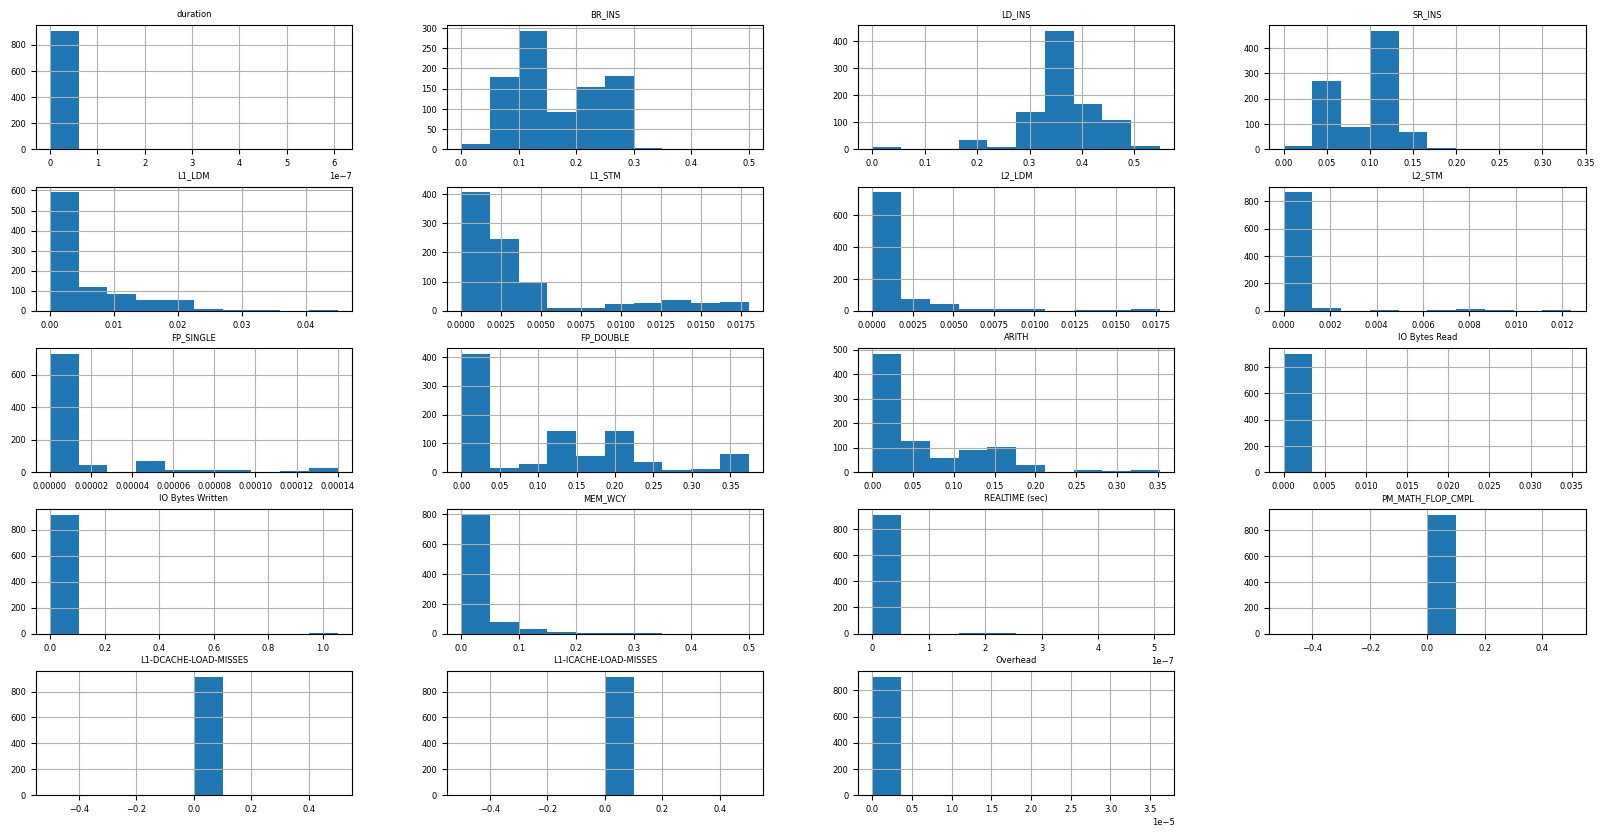

ruby ----------------------------------------------------------------------------------



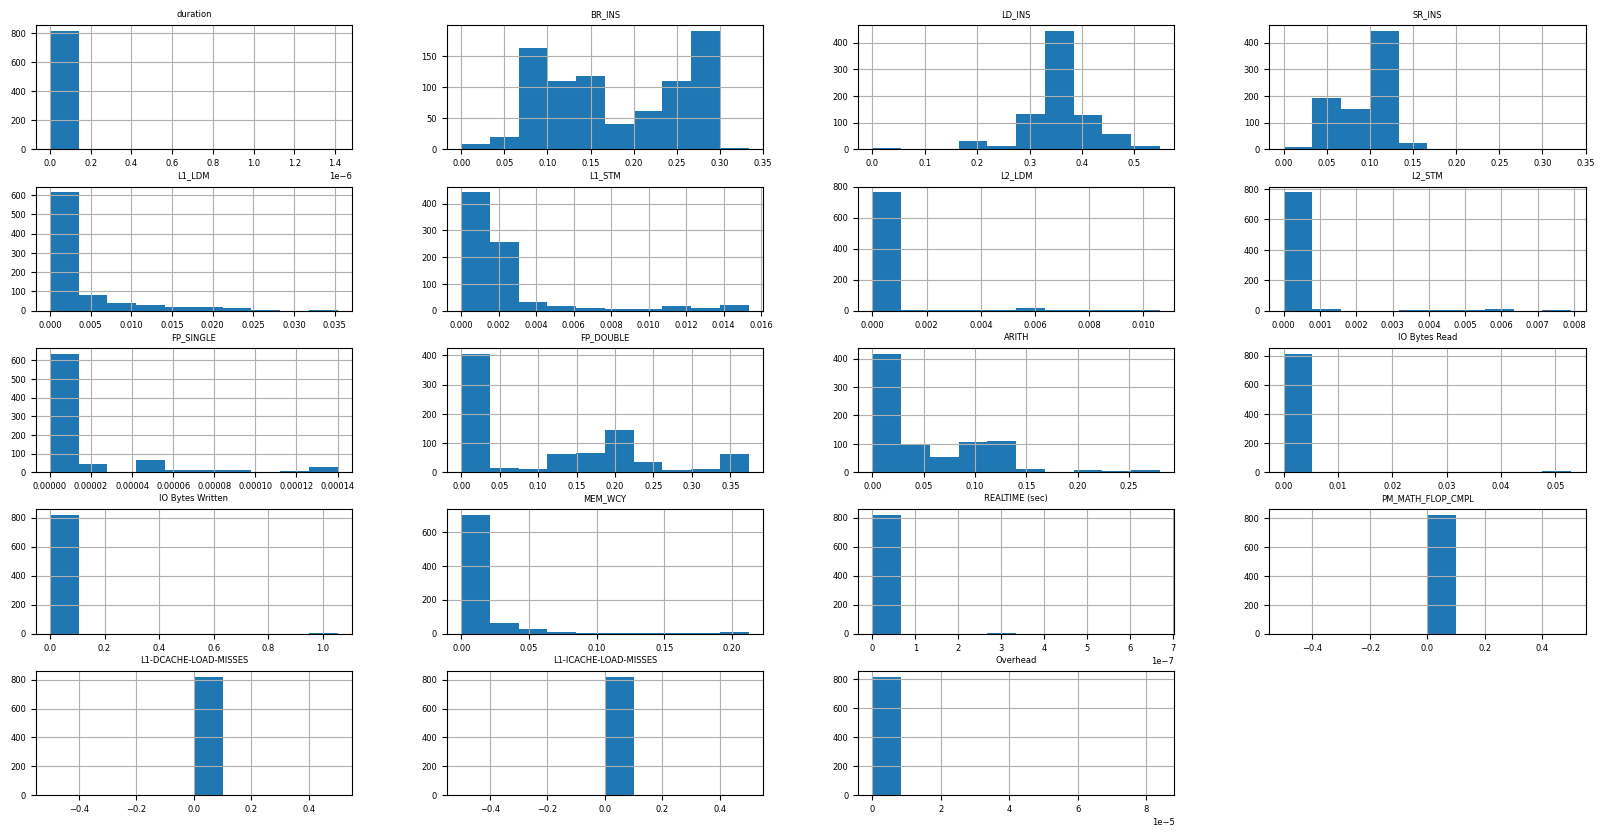

lassen ----------------------------------------------------------------------------------



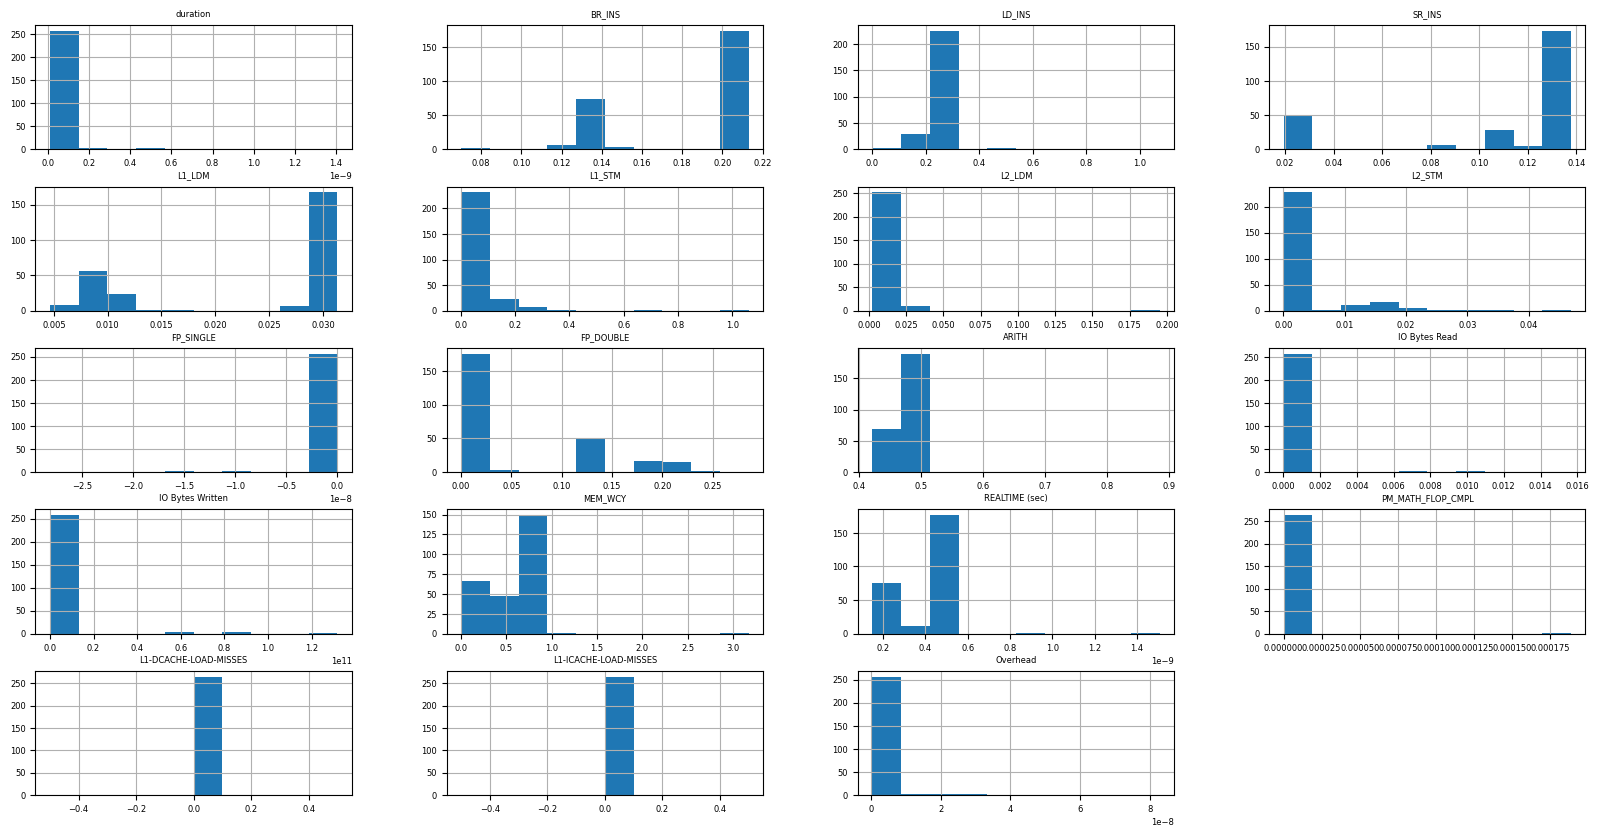

corona ----------------------------------------------------------------------------------



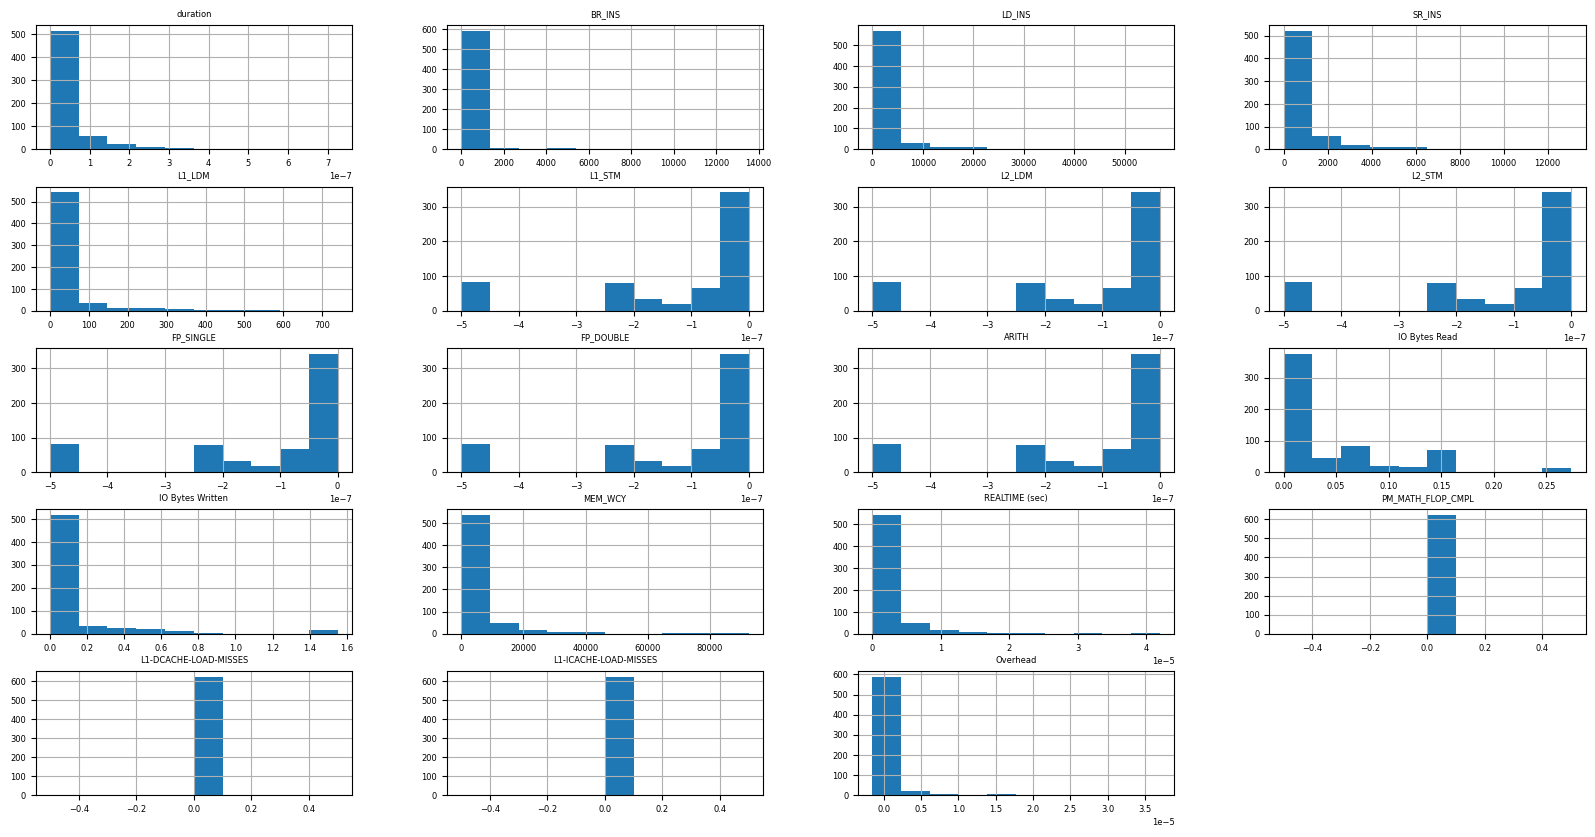

In [7]:
cols_to_exclude = ['machine', 'app', 'args', 'ranks']
for machine in all_machines:
    print("%s ----------------------------------------------------------------------------------\n" % machine)
    data_machine = refined_df.loc[refined_df['machine'] == machine, ~refined_df.columns.isin(cols_to_exclude)]
    if data_machine.empty:
        continue
    data_machine.hist()
    plt.savefig('hist.' + machine + '.png')
    plt.show()

## Histogram of each column per app per machine

laghos on quartz ----------------------------------------------------------------------------------



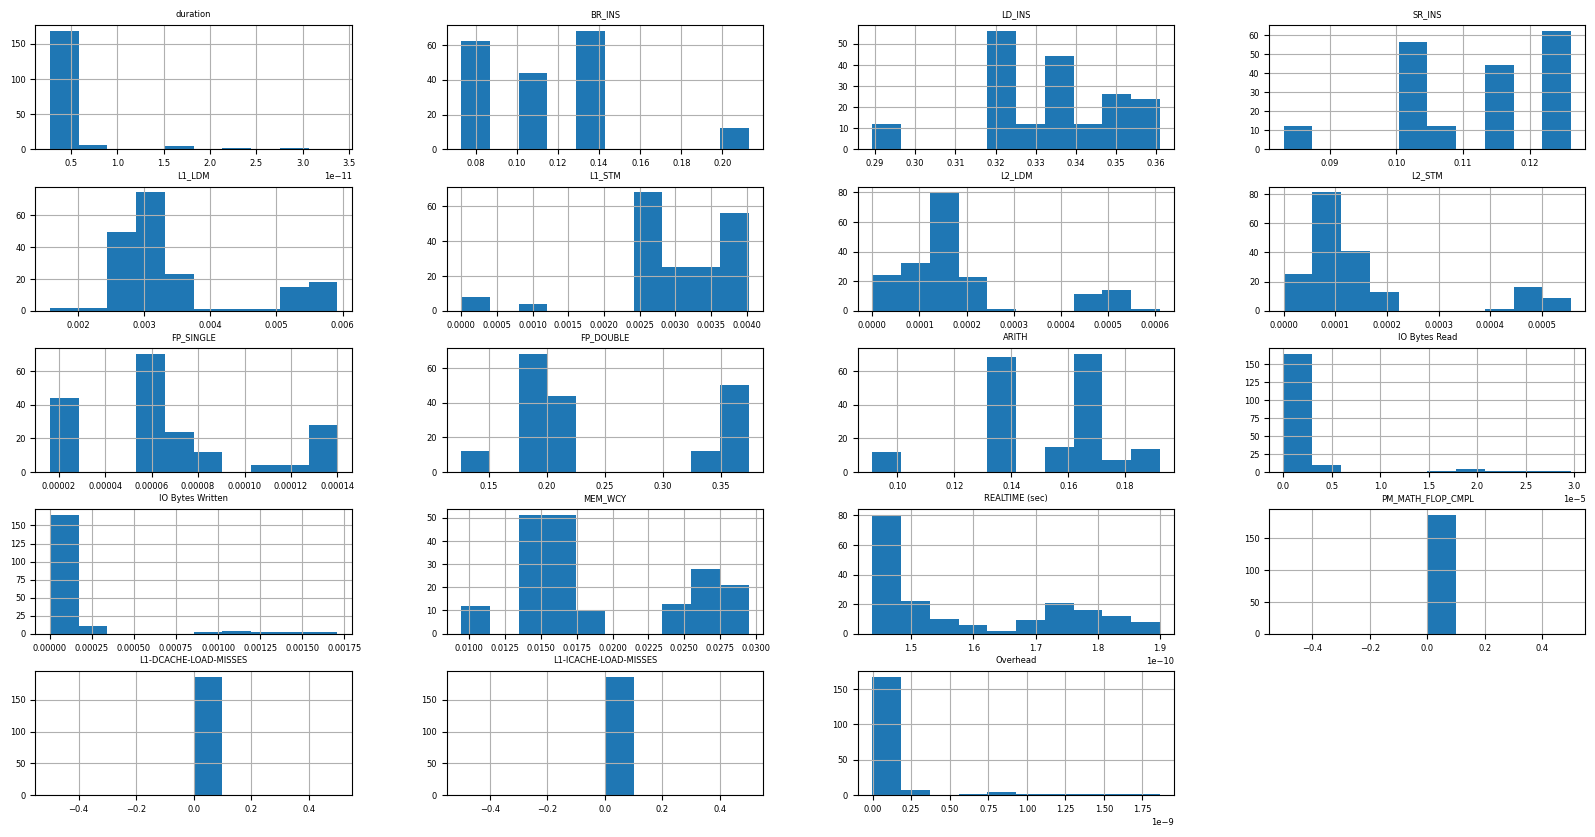

kripke.exe on quartz ----------------------------------------------------------------------------------



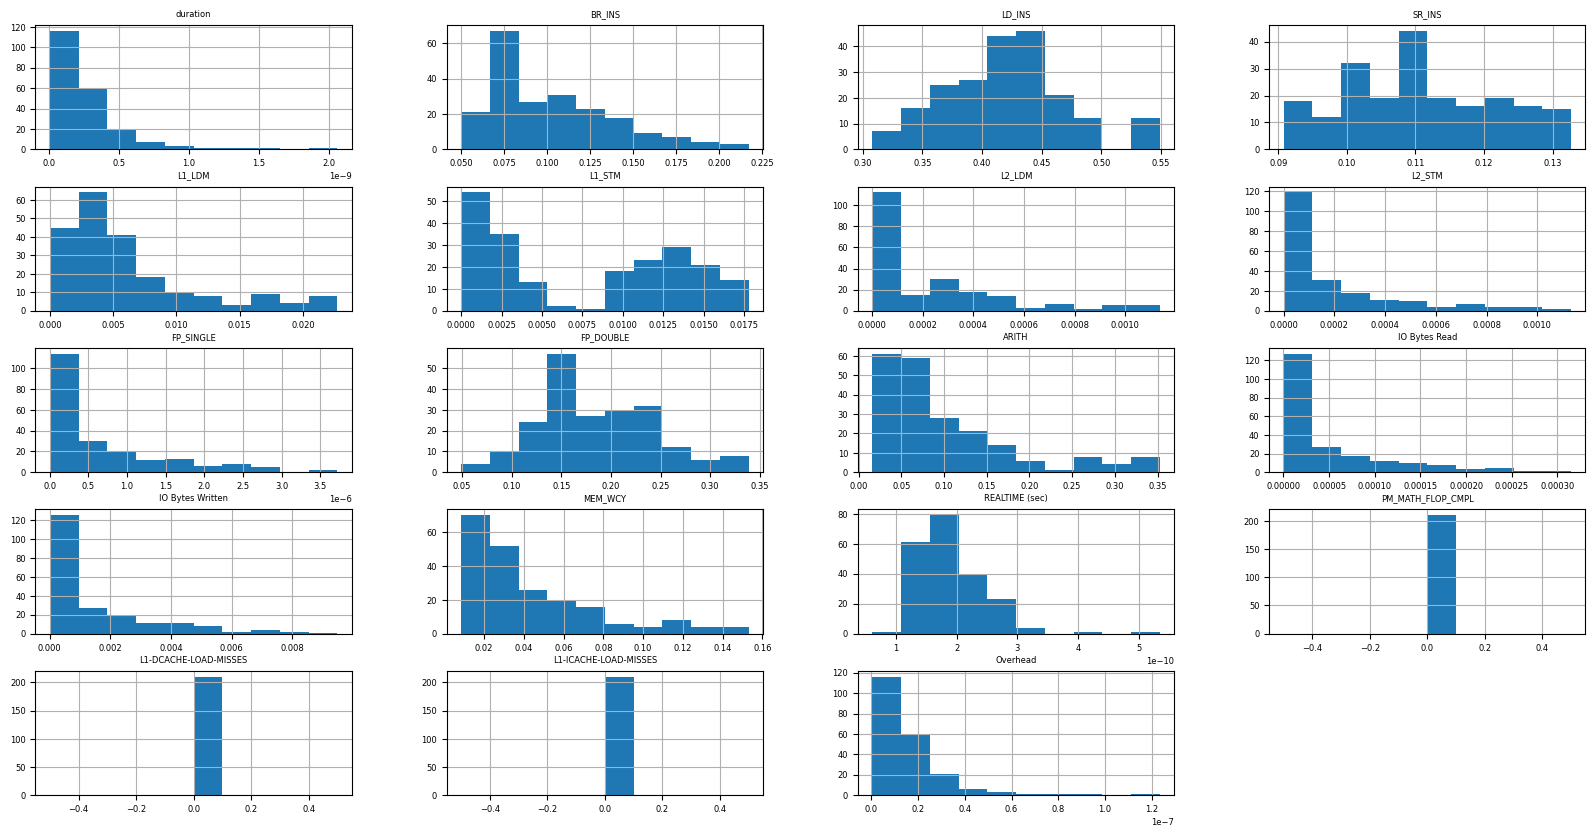

sw4lite on quartz ----------------------------------------------------------------------------------



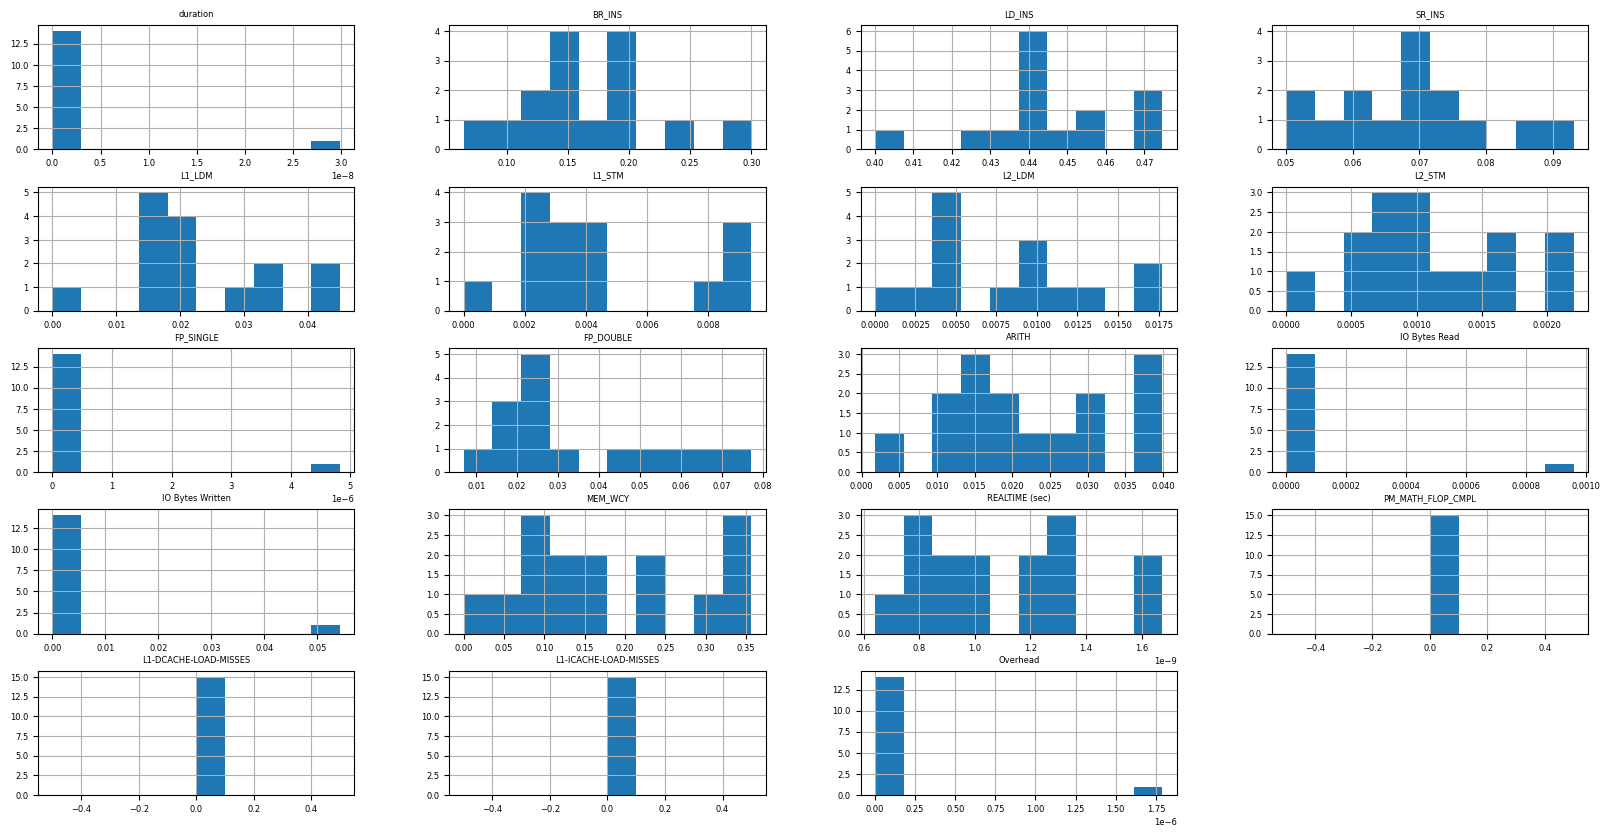

miniVite on quartz ----------------------------------------------------------------------------------



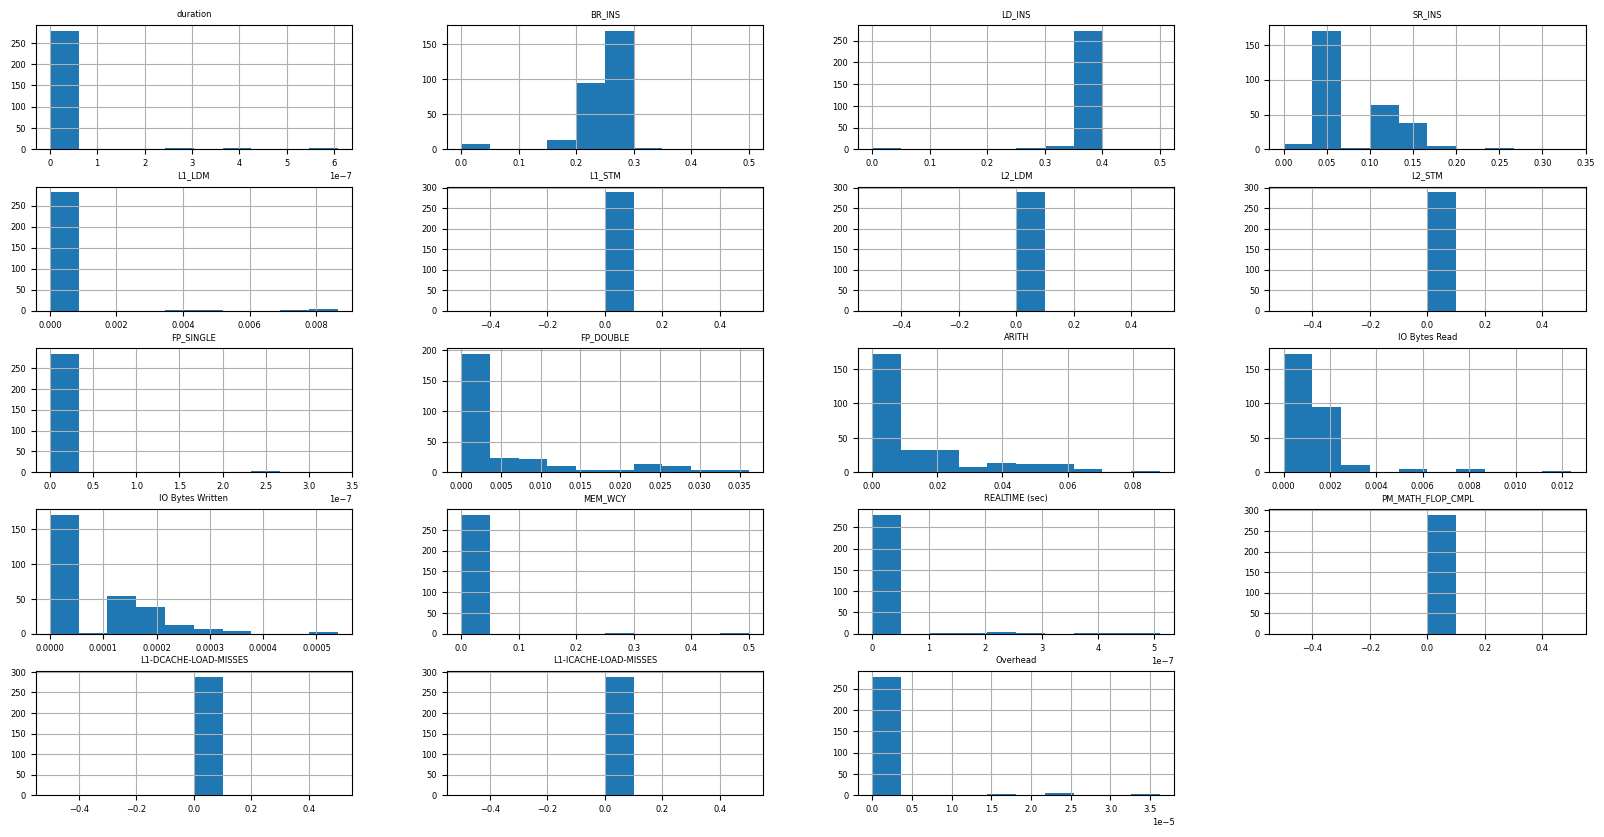

TestDfft on quartz ----------------------------------------------------------------------------------



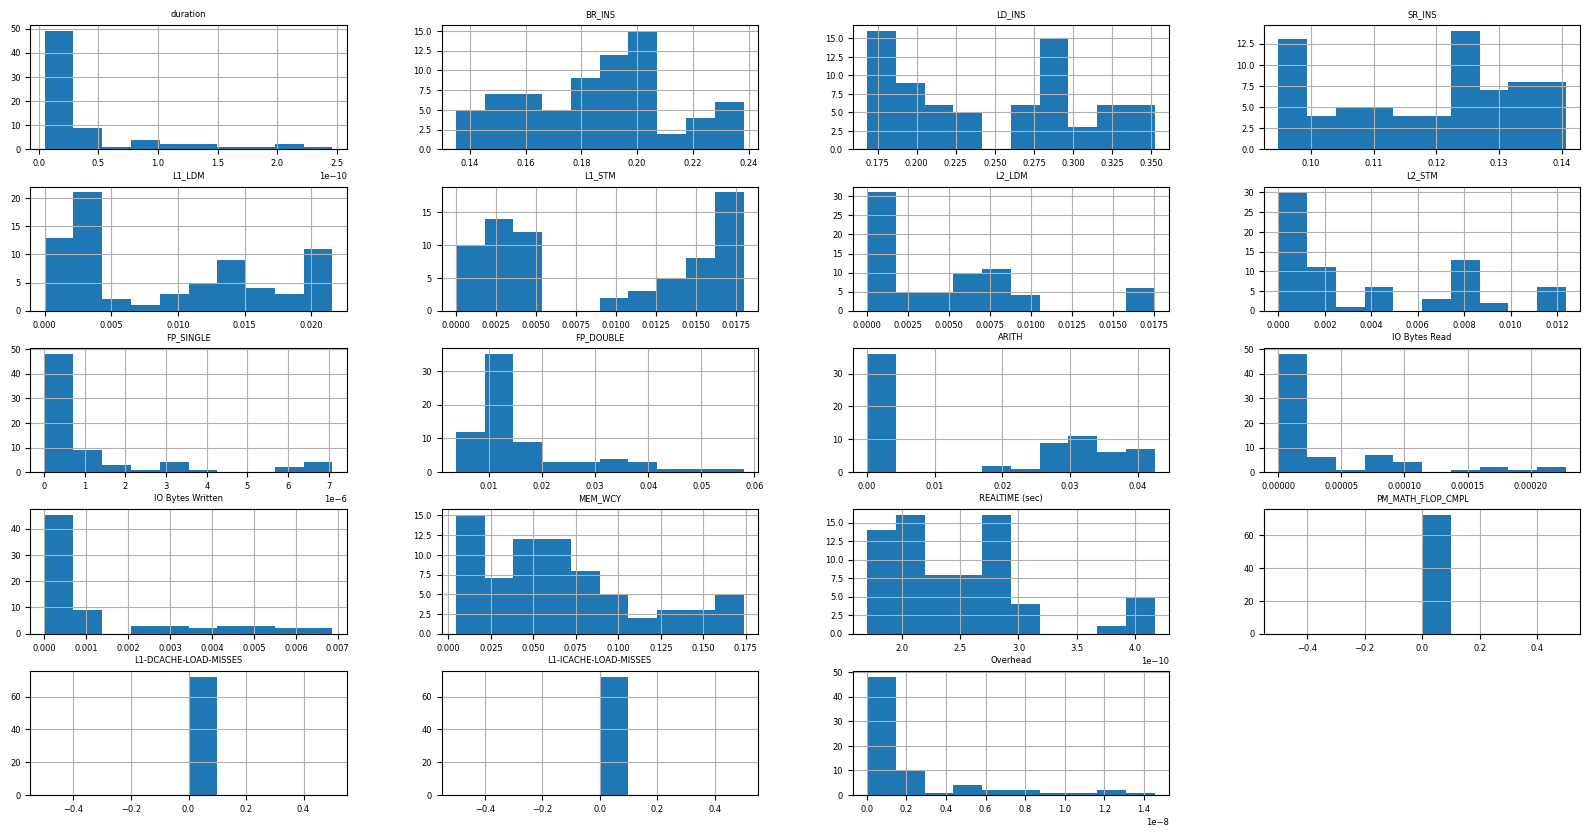

amg on quartz ----------------------------------------------------------------------------------



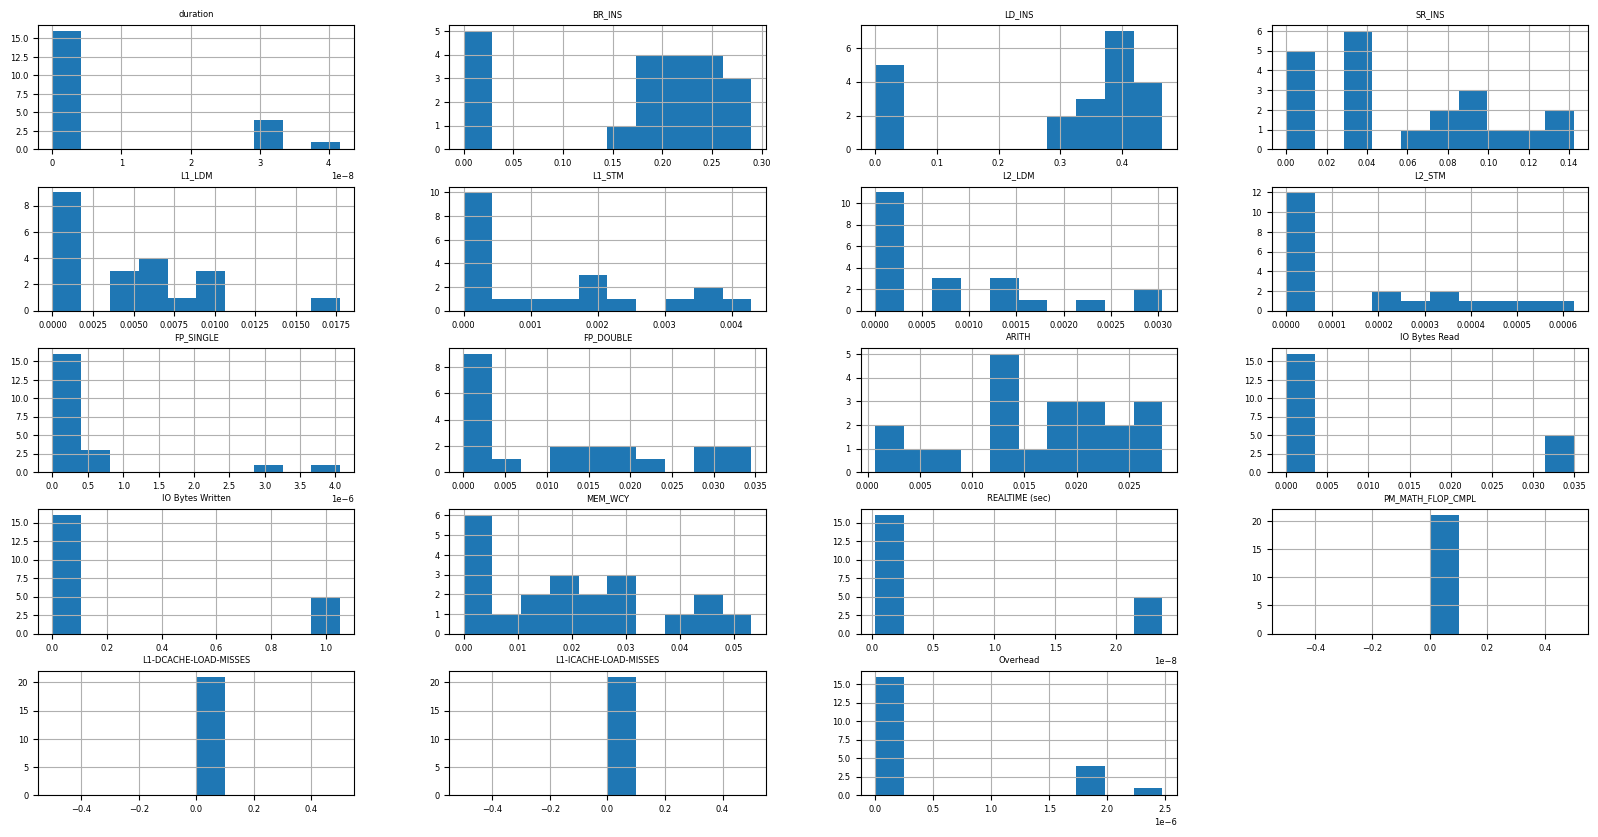

XSBench on quartz ----------------------------------------------------------------------------------



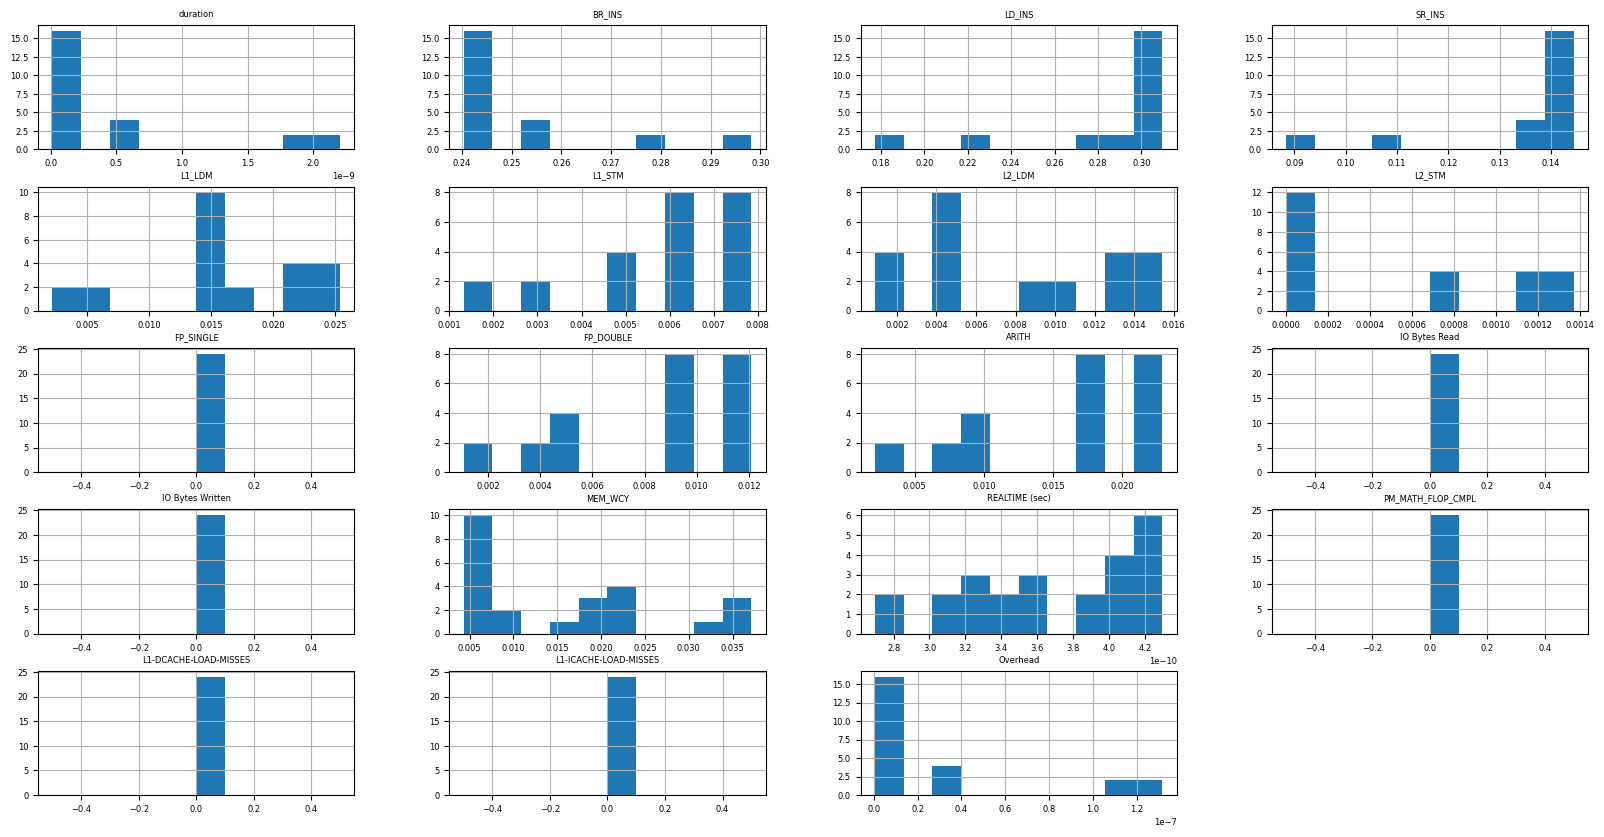

miniFE.x on quartz ----------------------------------------------------------------------------------



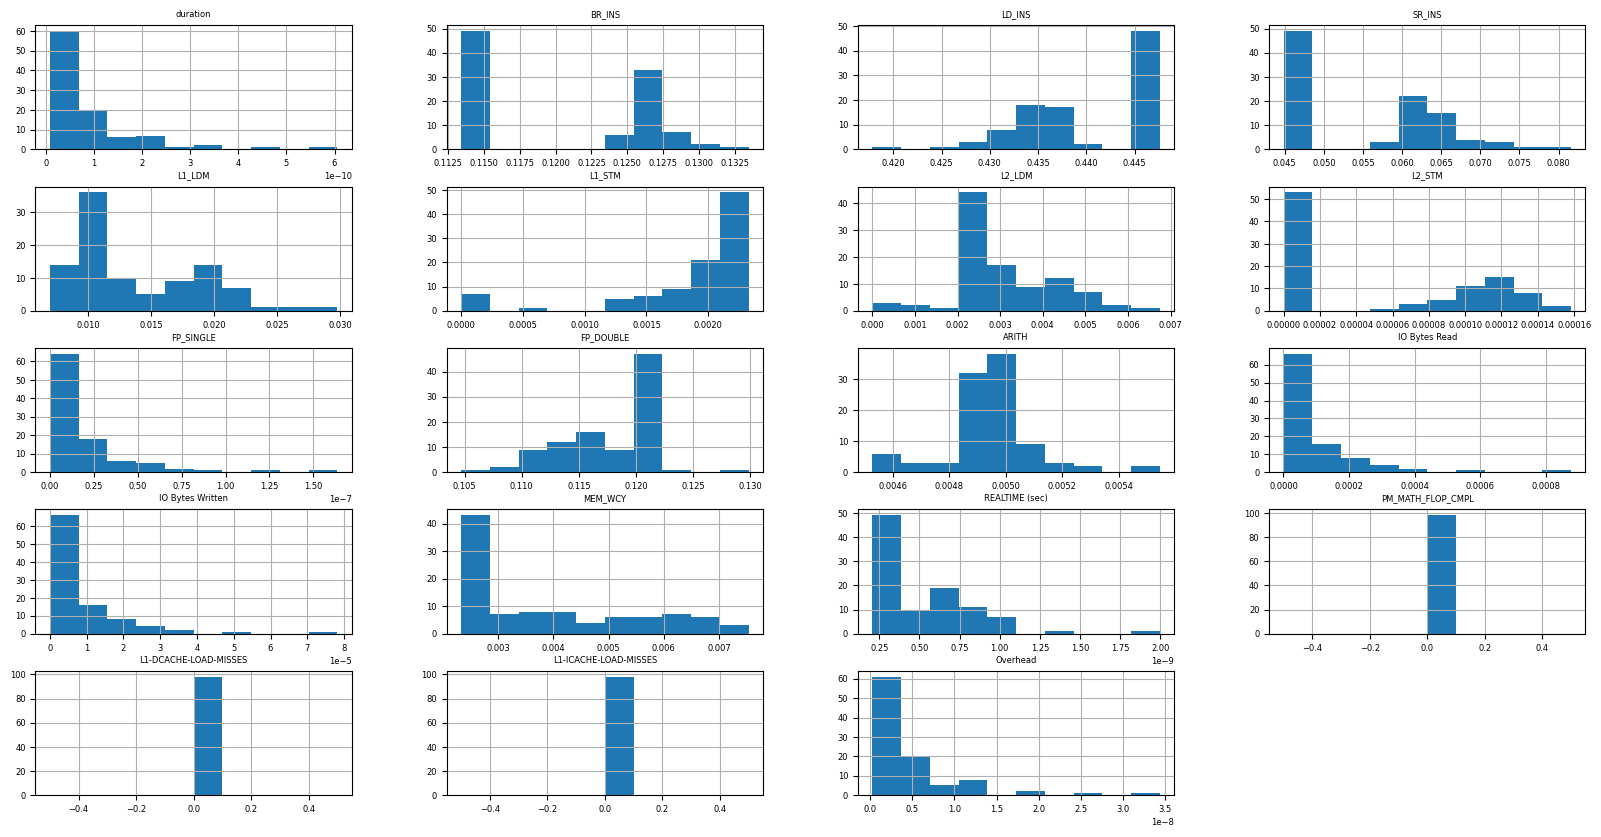

laghos on ruby ----------------------------------------------------------------------------------



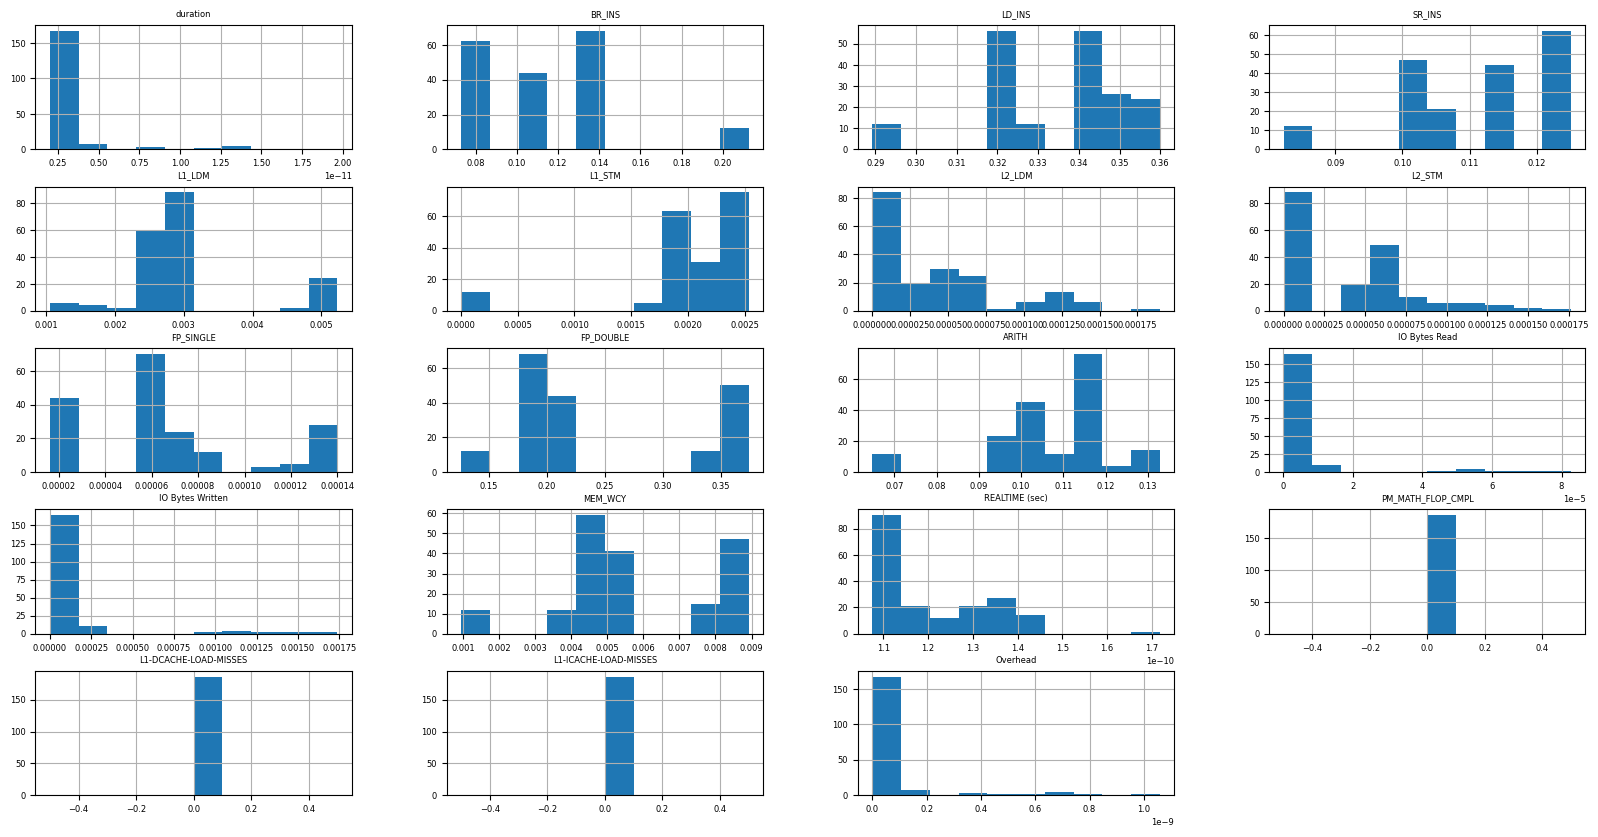

kripke.exe on ruby ----------------------------------------------------------------------------------



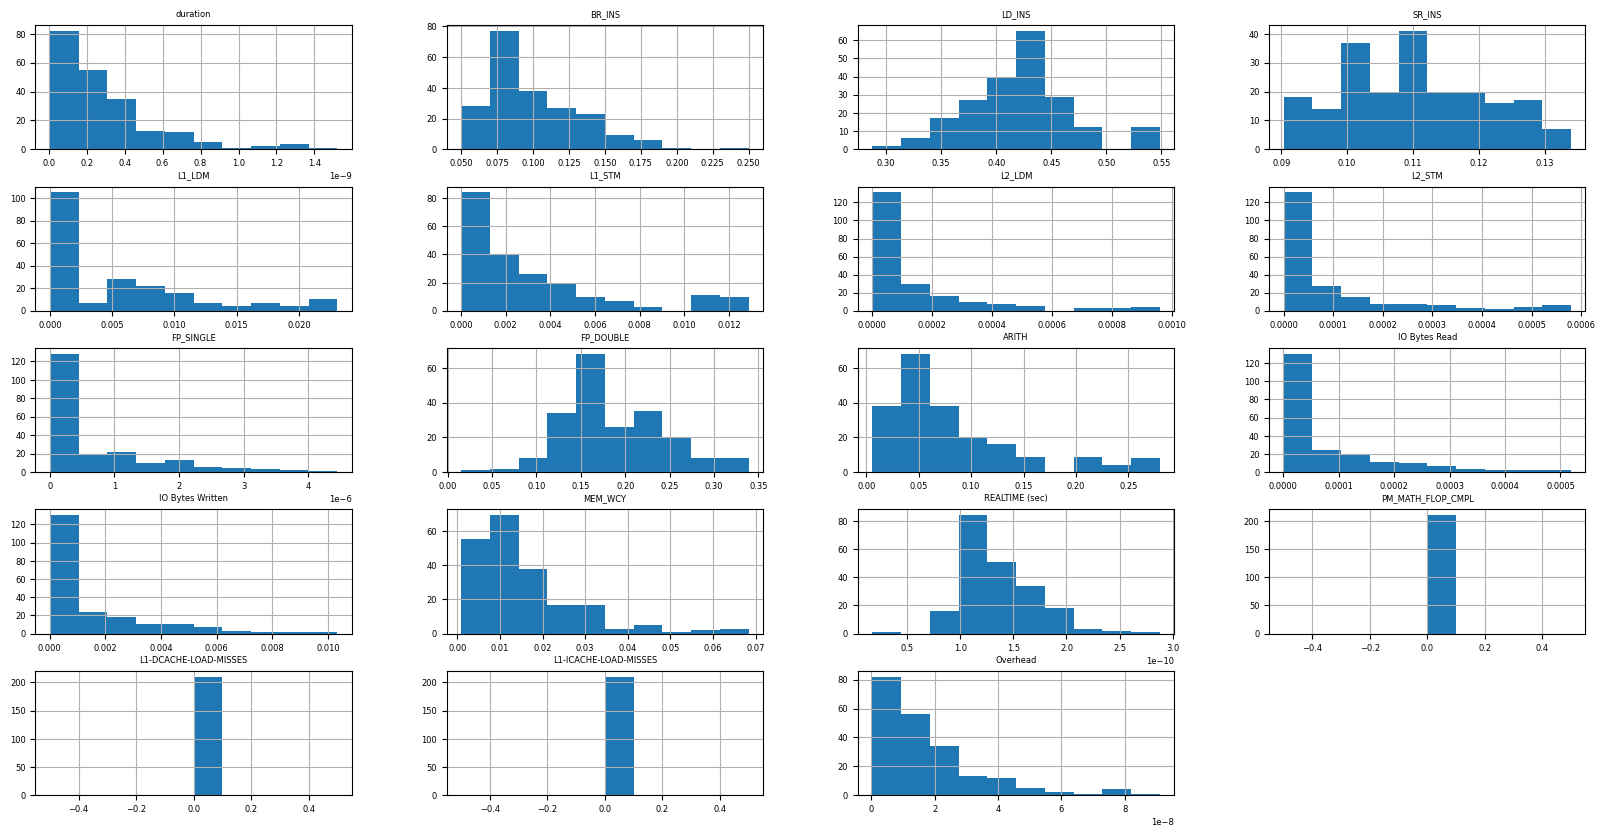

sw4lite on ruby ----------------------------------------------------------------------------------



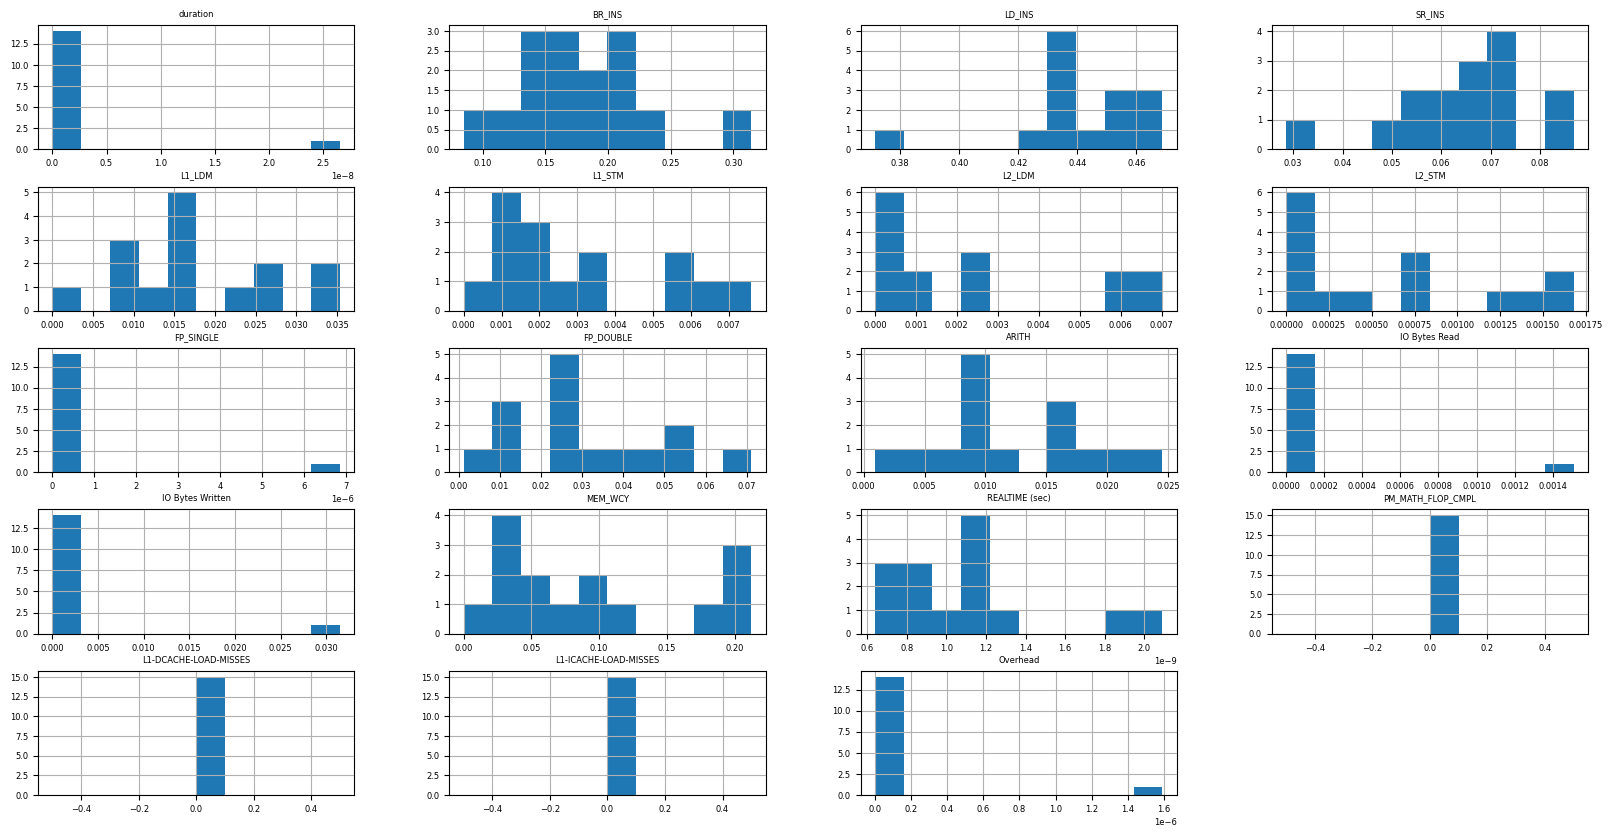

miniVite on ruby ----------------------------------------------------------------------------------



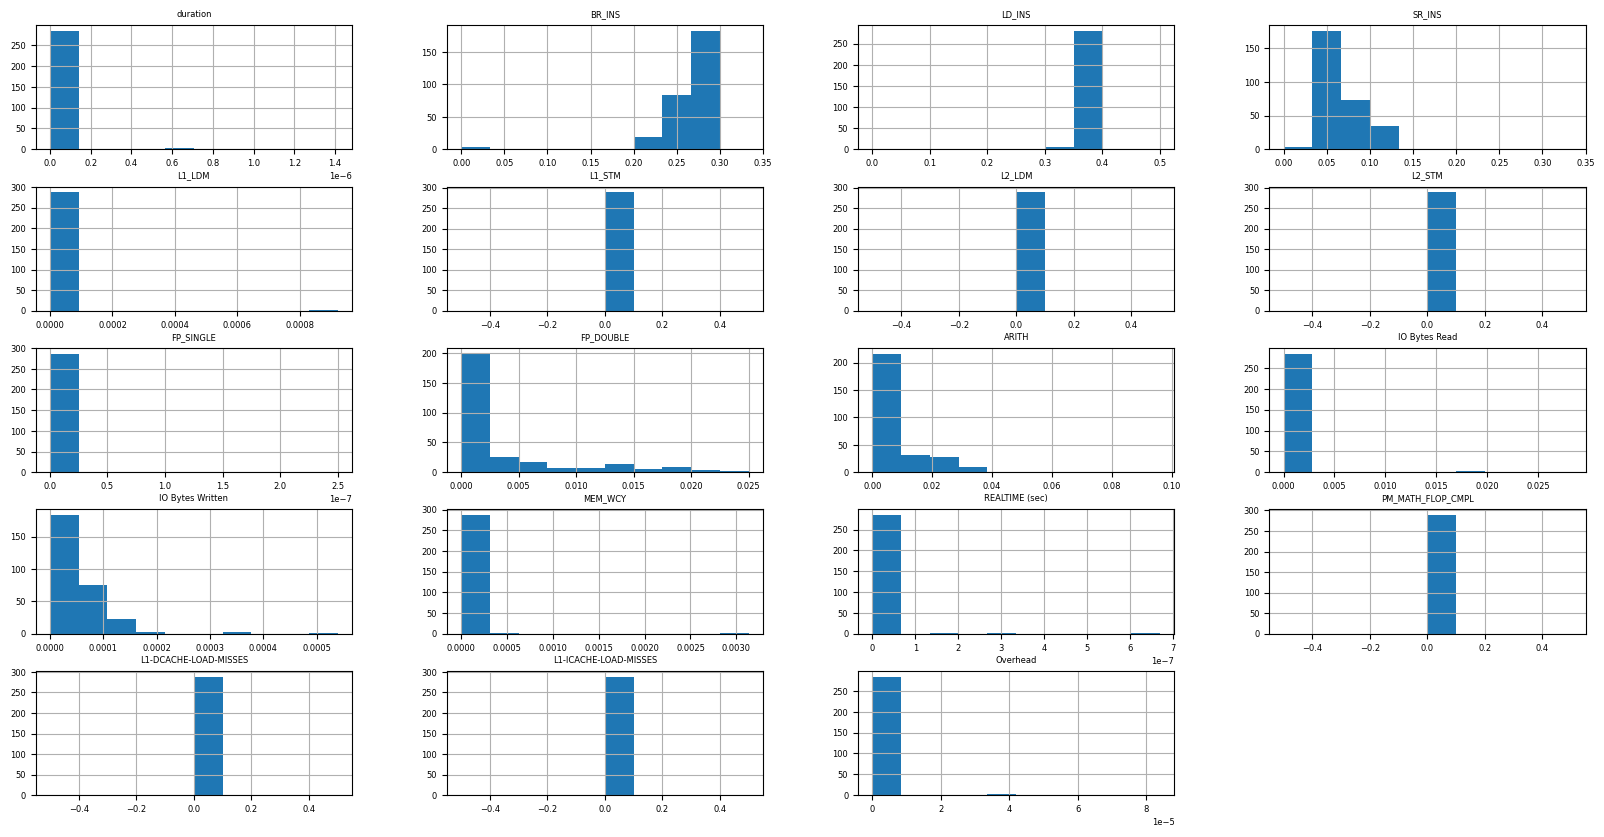

TestDfft on ruby ----------------------------------------------------------------------------------



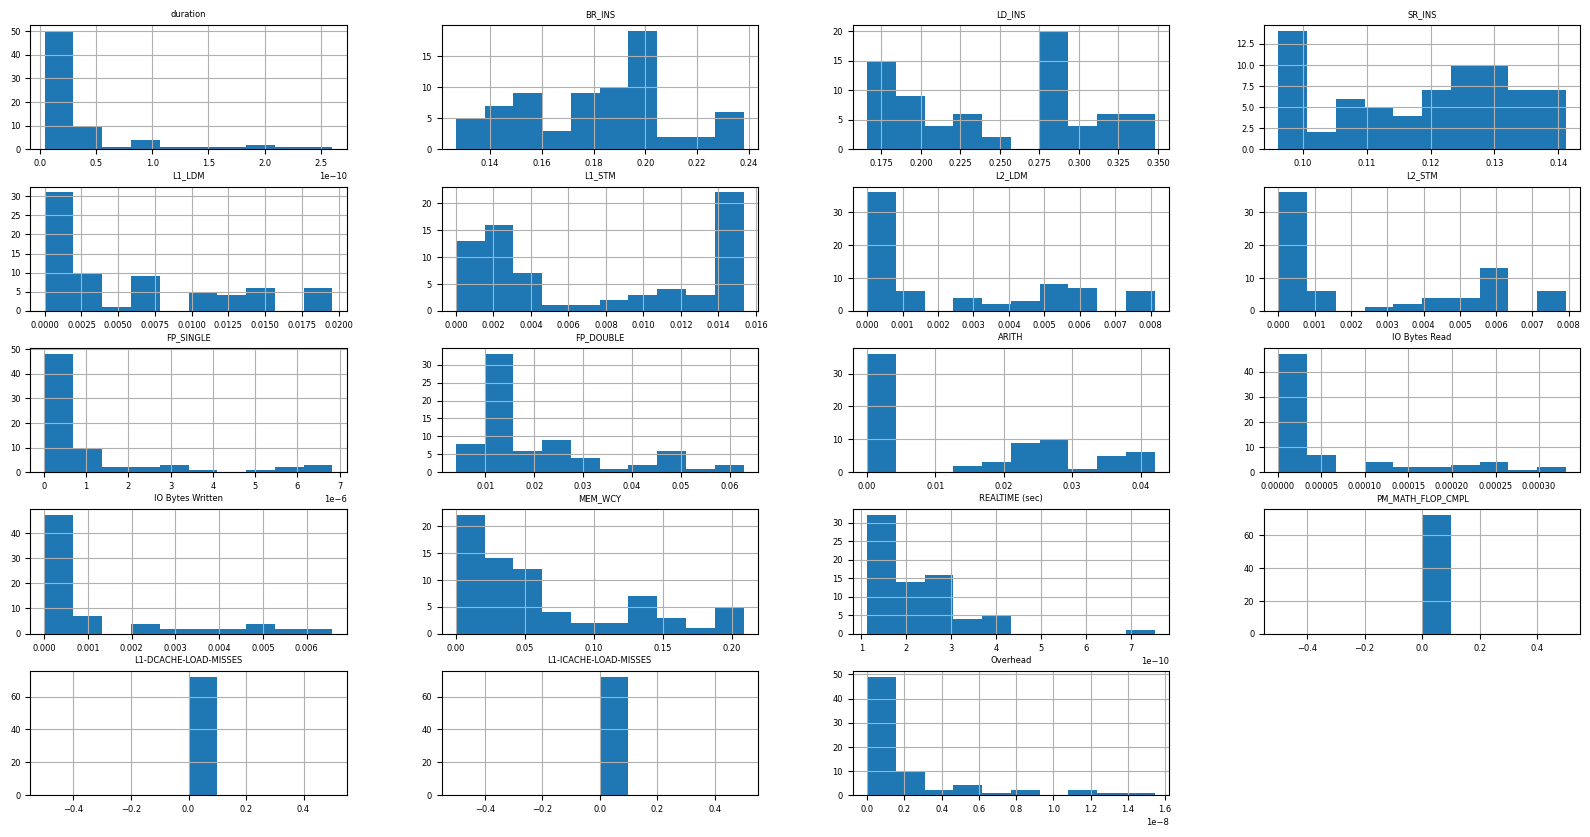

amg on ruby ----------------------------------------------------------------------------------



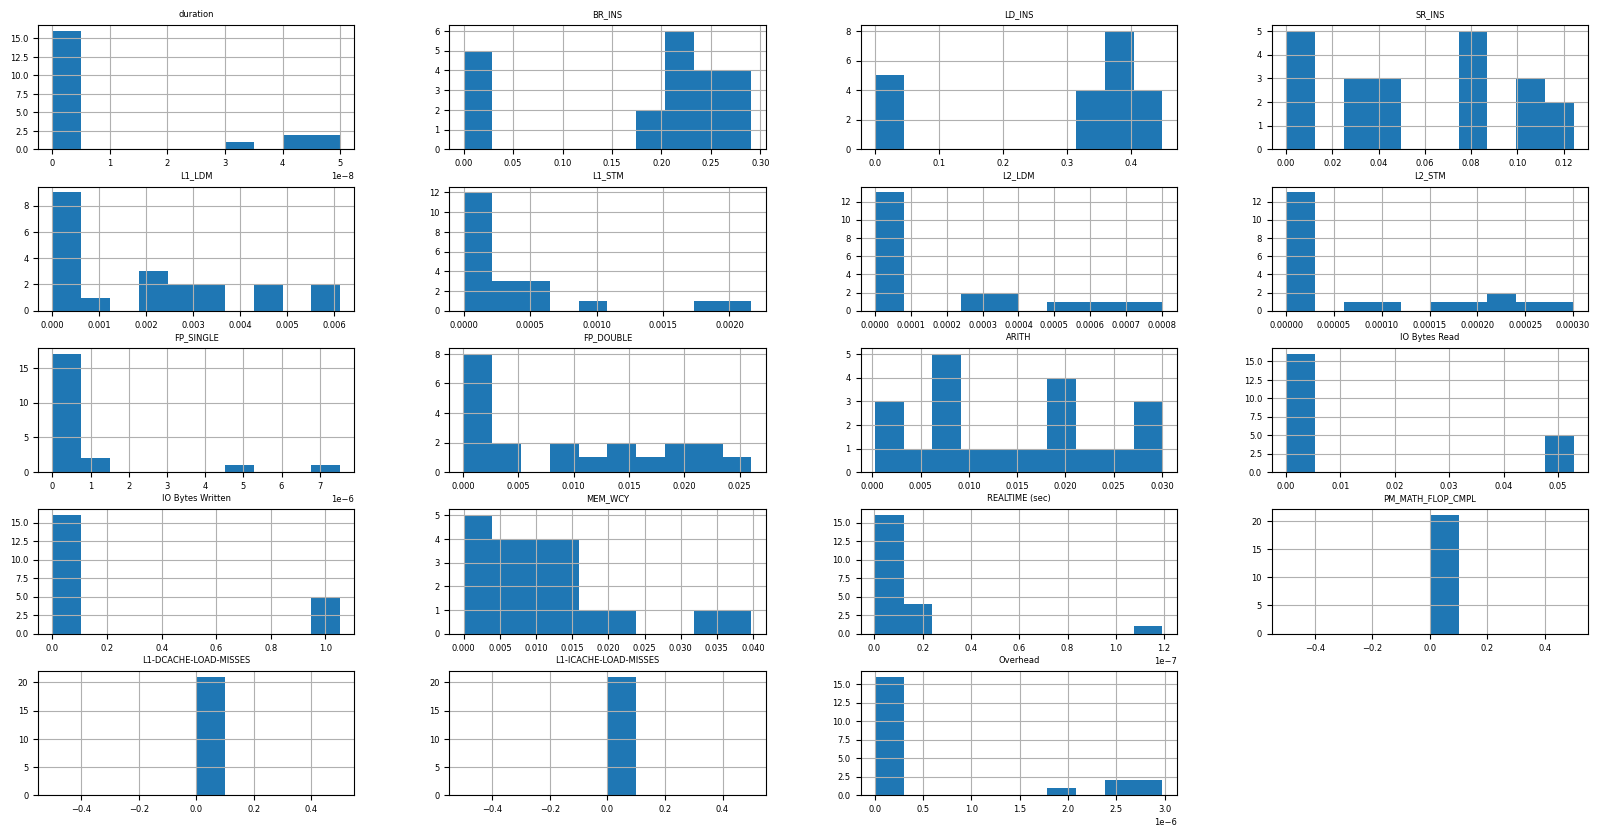

XSBench on ruby ----------------------------------------------------------------------------------



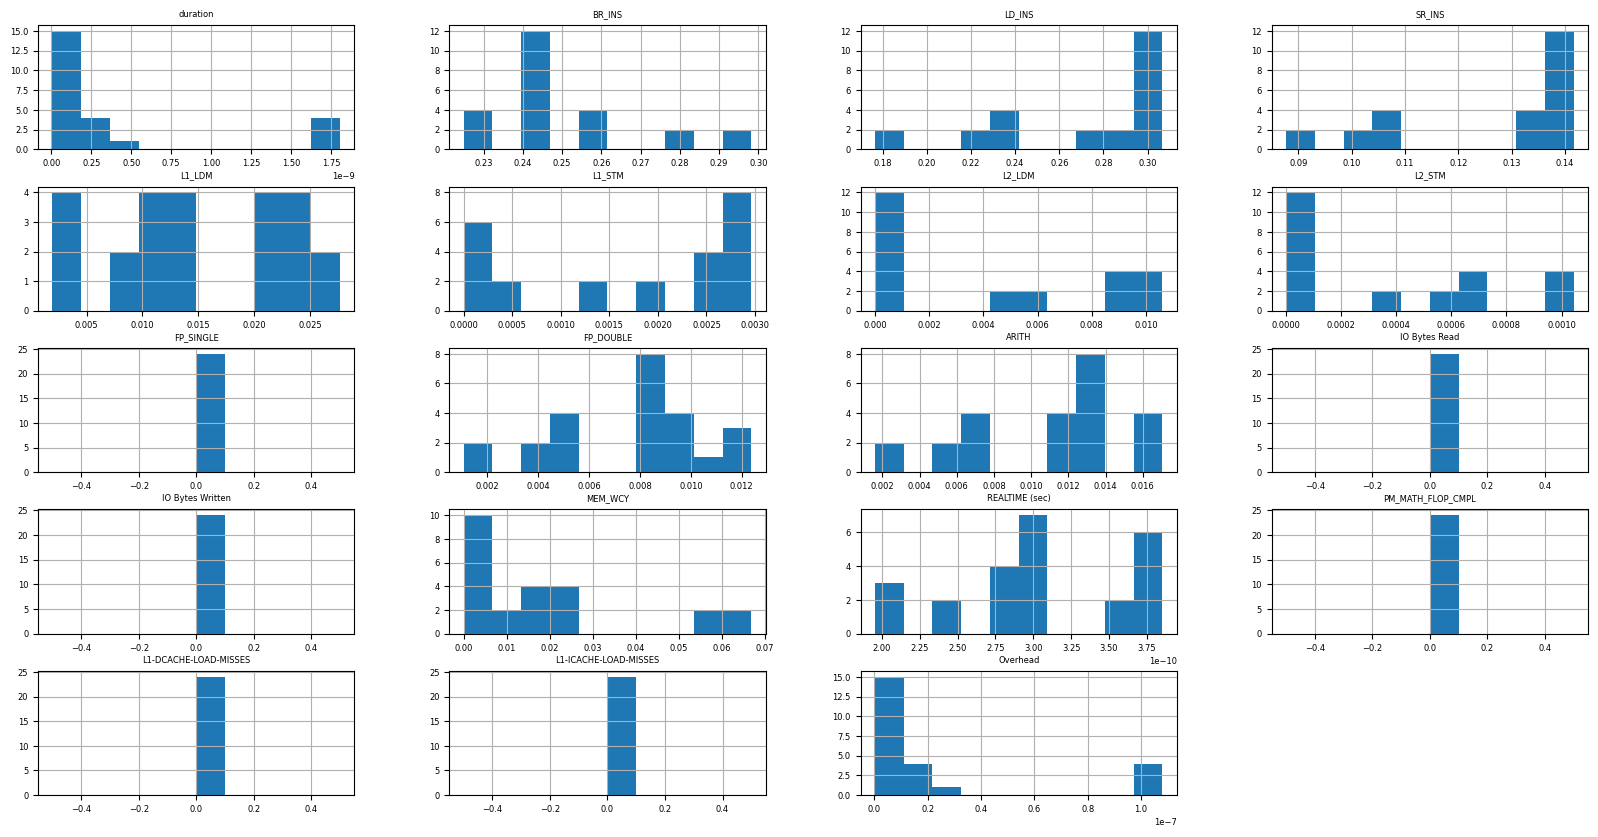

miniFE.x on ruby ----------------------------------------------------------------------------------



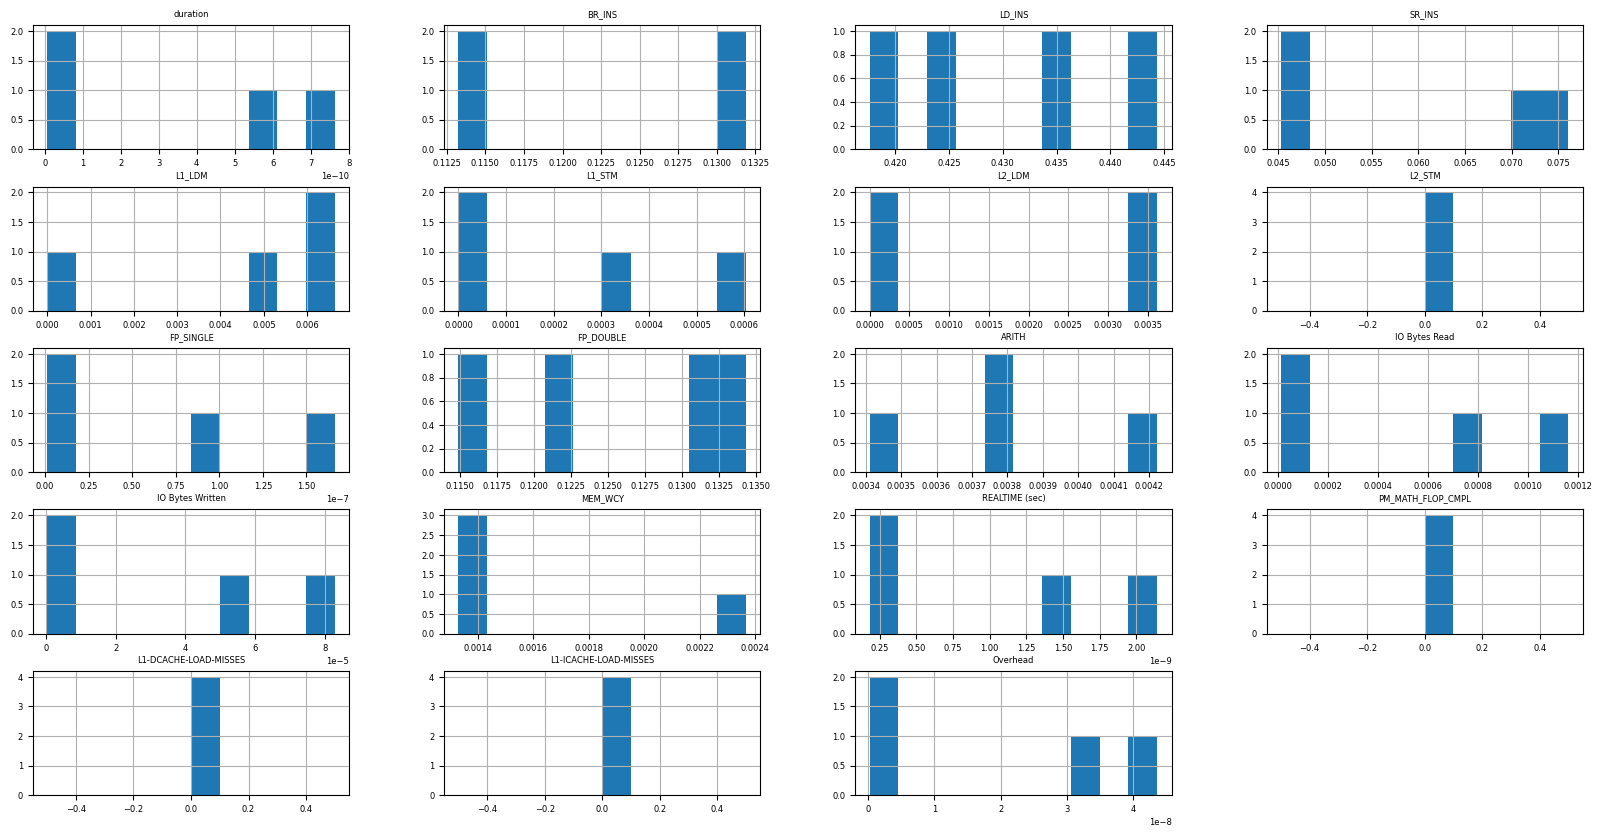

laghos on lassen ----------------------------------------------------------------------------------



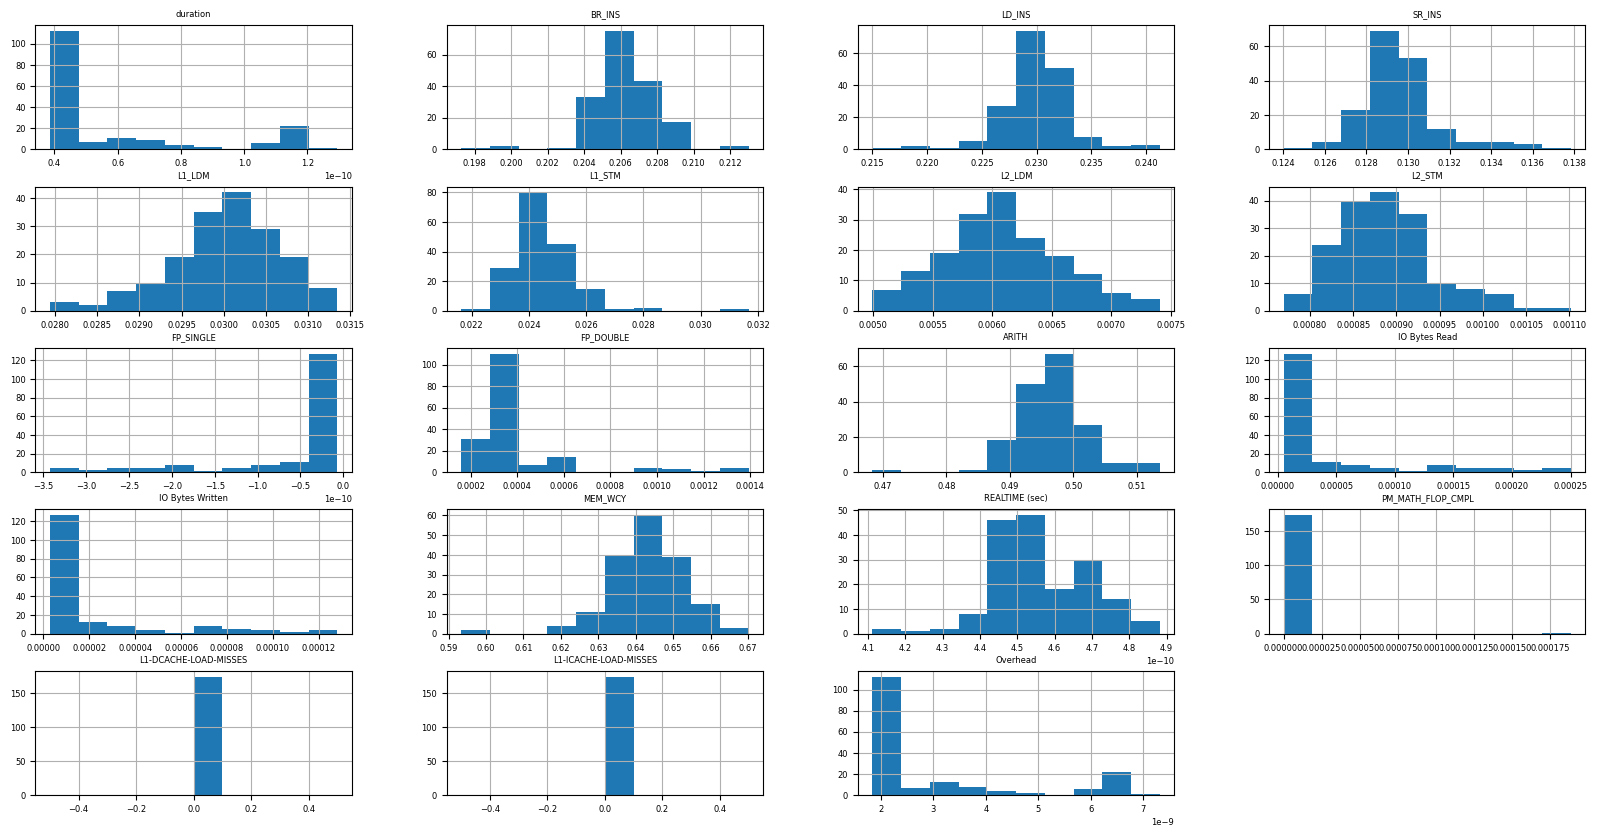

kripke.exe on lassen ----------------------------------------------------------------------------------

sw4lite on lassen ----------------------------------------------------------------------------------

miniVite on lassen ----------------------------------------------------------------------------------

TestDfft on lassen ----------------------------------------------------------------------------------



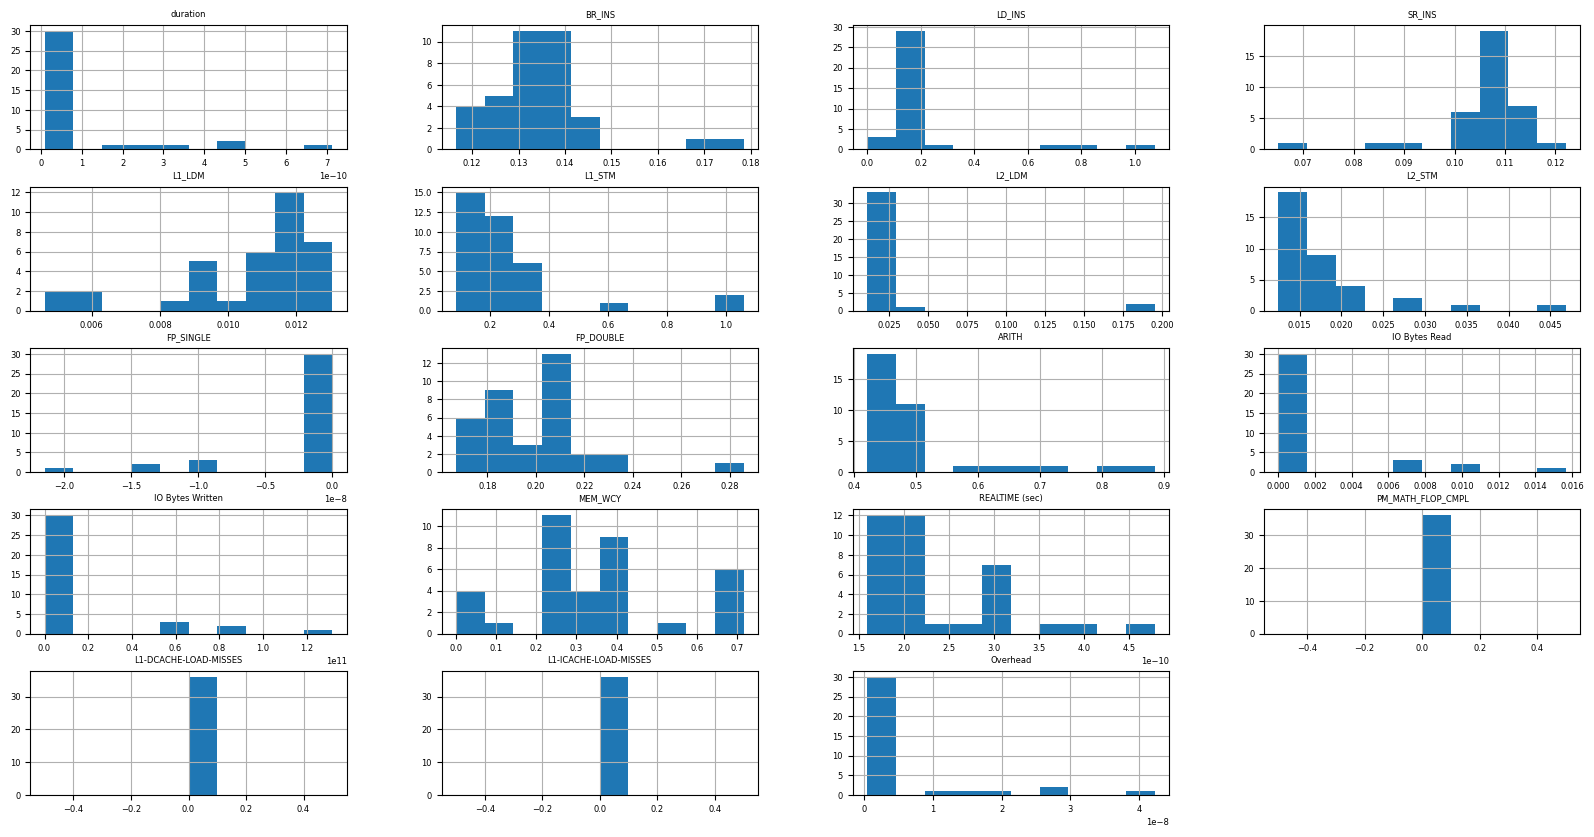

amg on lassen ----------------------------------------------------------------------------------



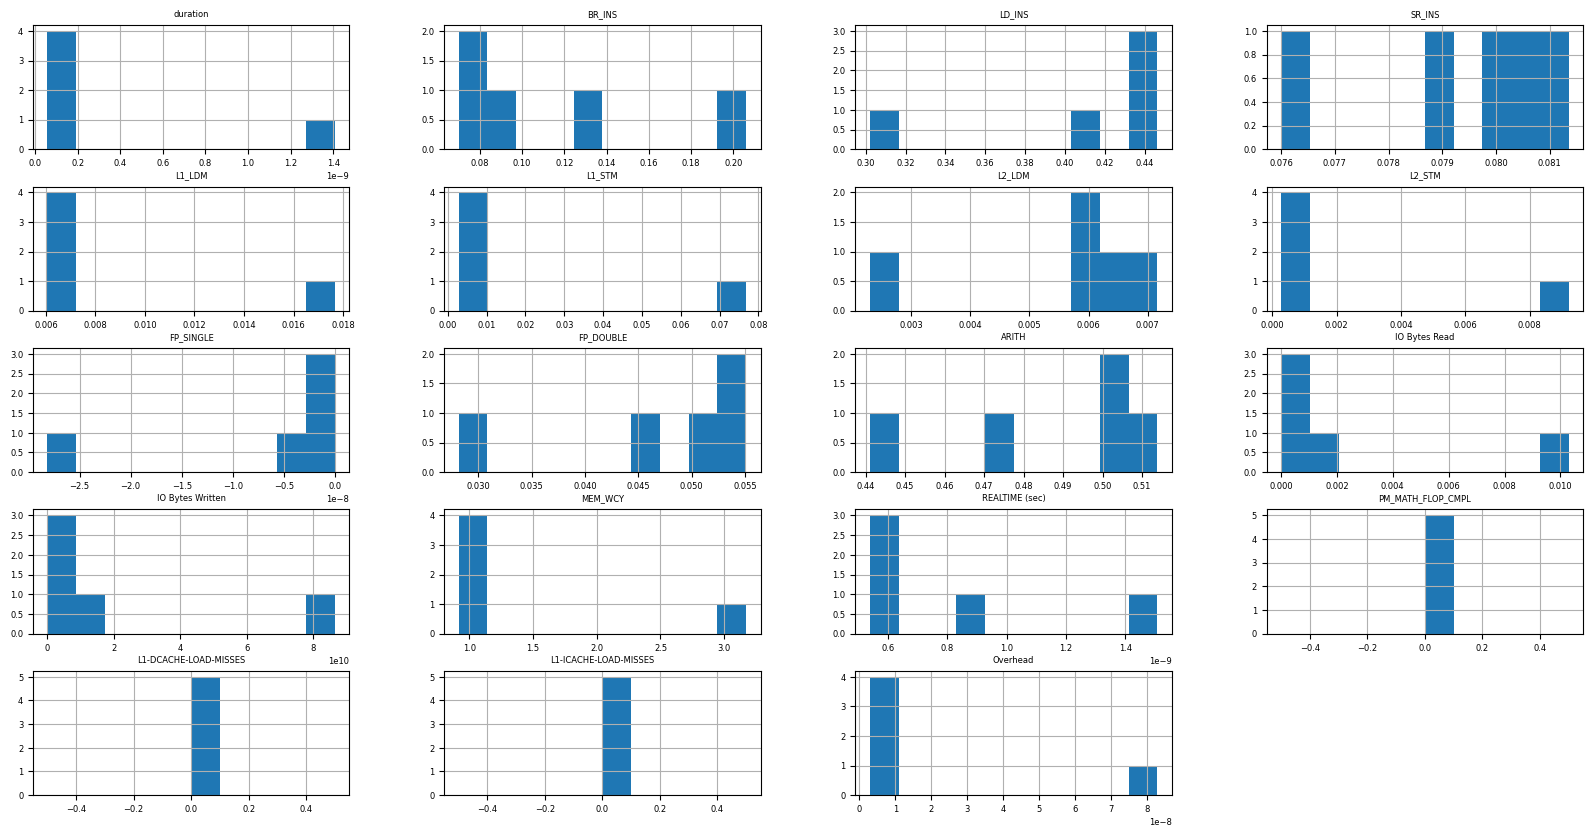

XSBench on lassen ----------------------------------------------------------------------------------

miniFE.x on lassen ----------------------------------------------------------------------------------



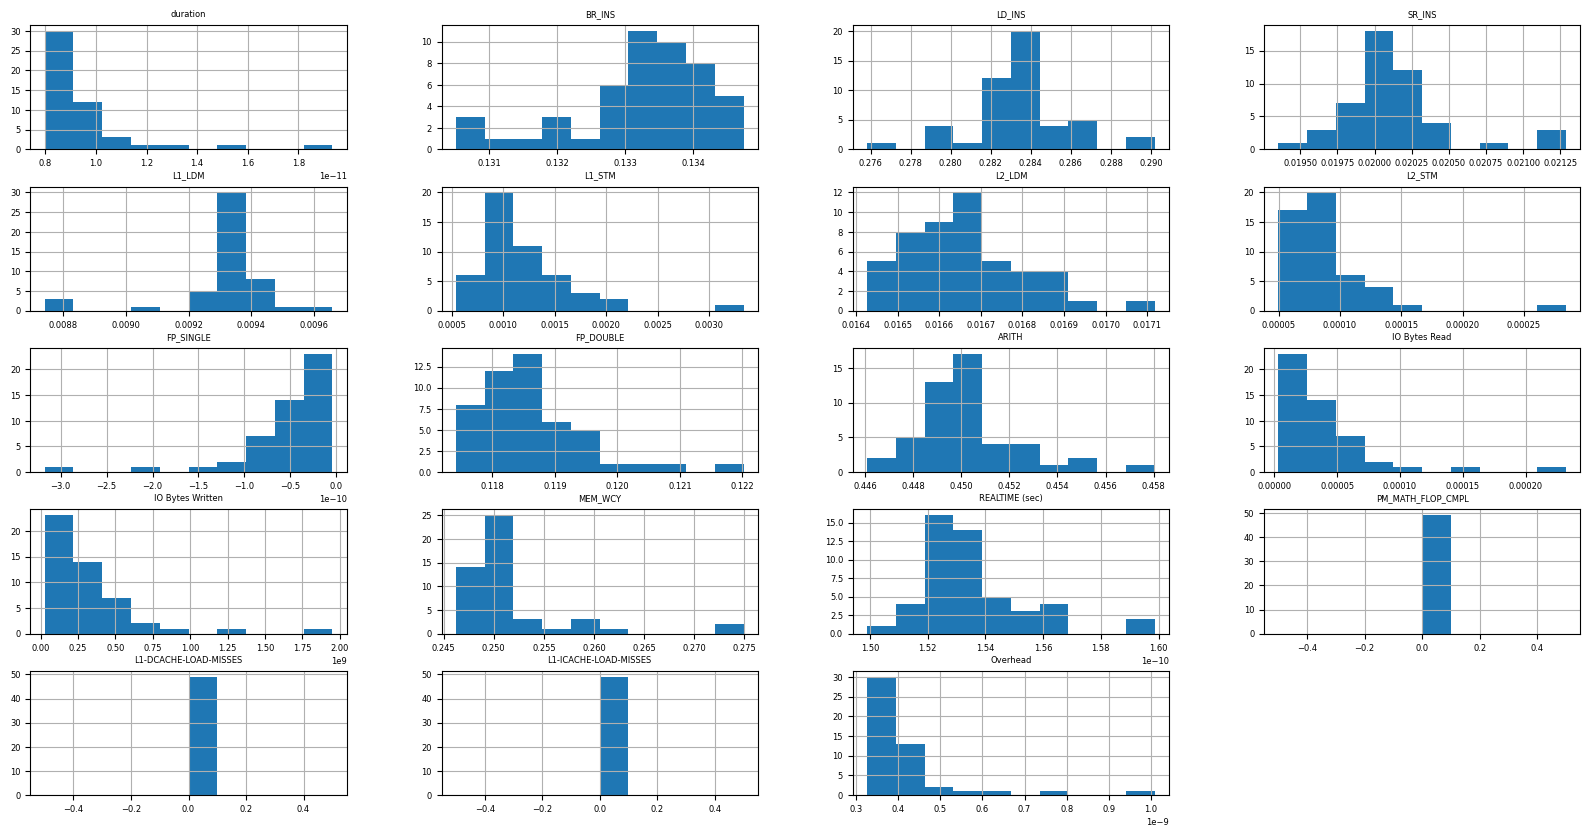

laghos on corona ----------------------------------------------------------------------------------



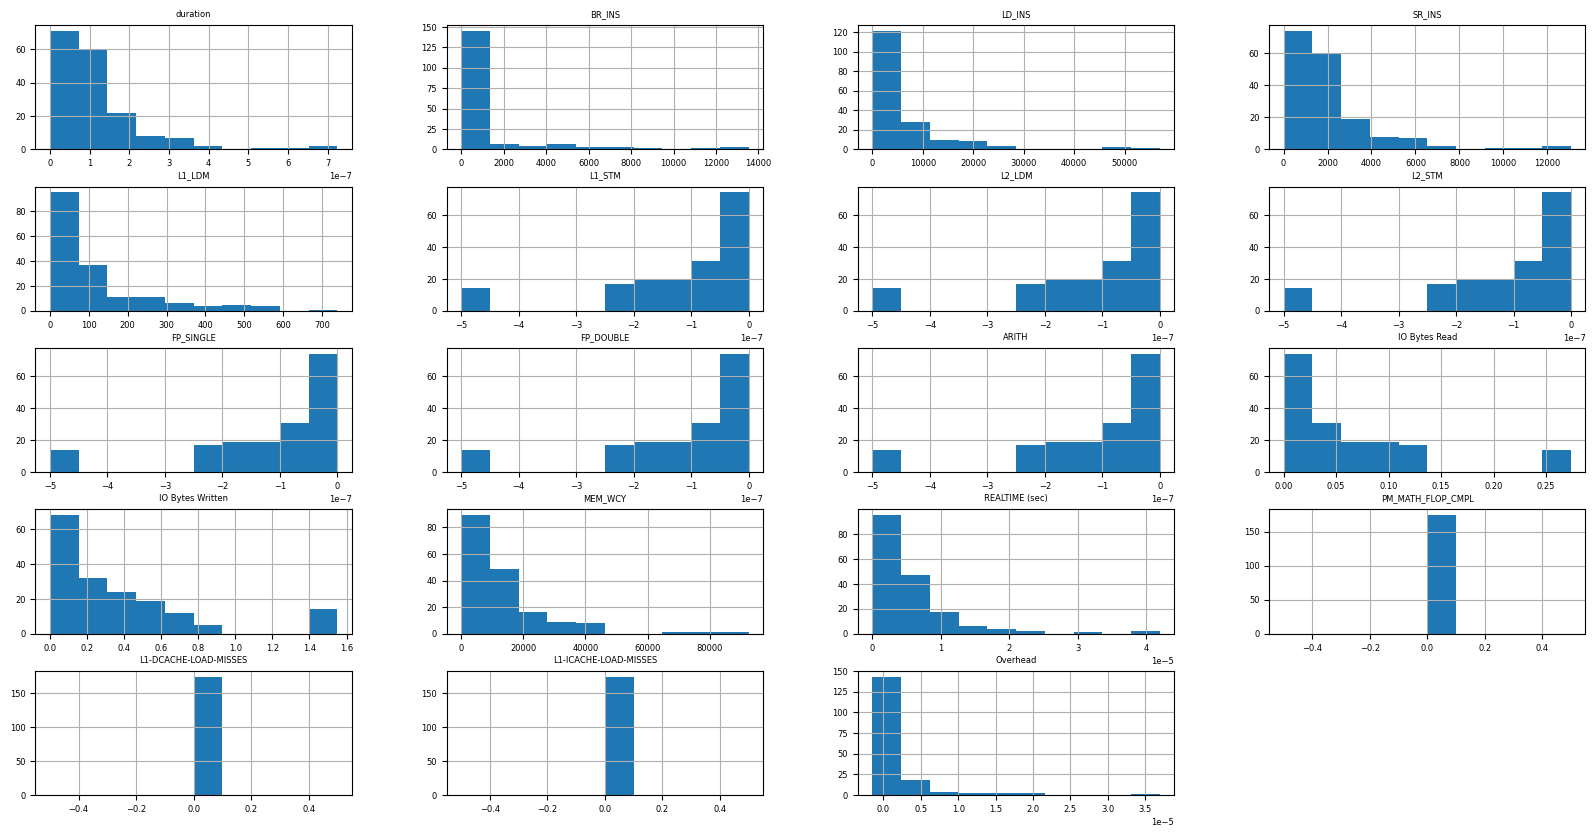

kripke.exe on corona ----------------------------------------------------------------------------------



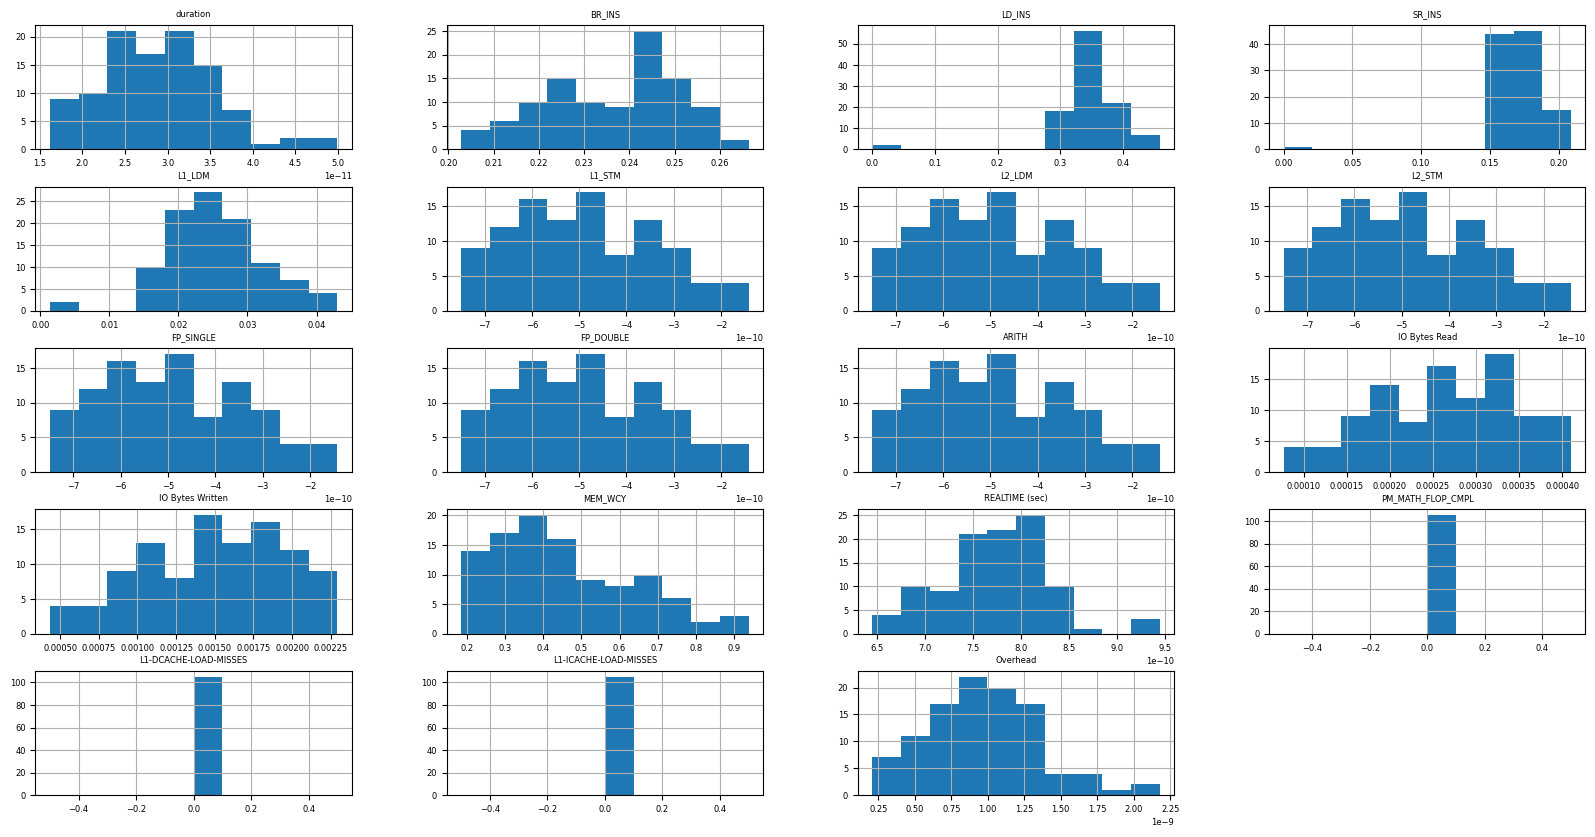

sw4lite on corona ----------------------------------------------------------------------------------



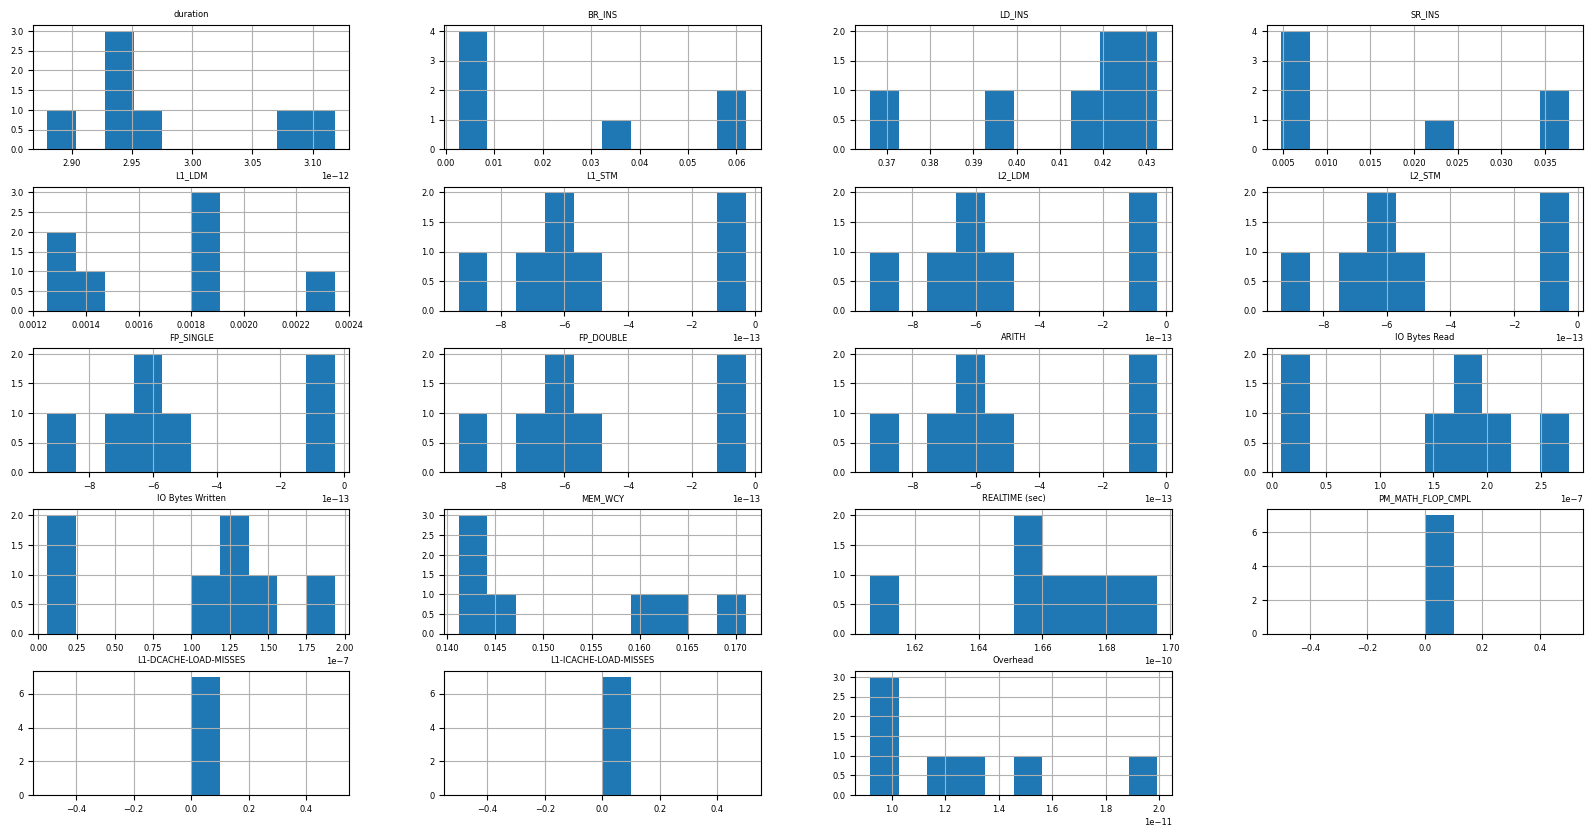

miniVite on corona ----------------------------------------------------------------------------------



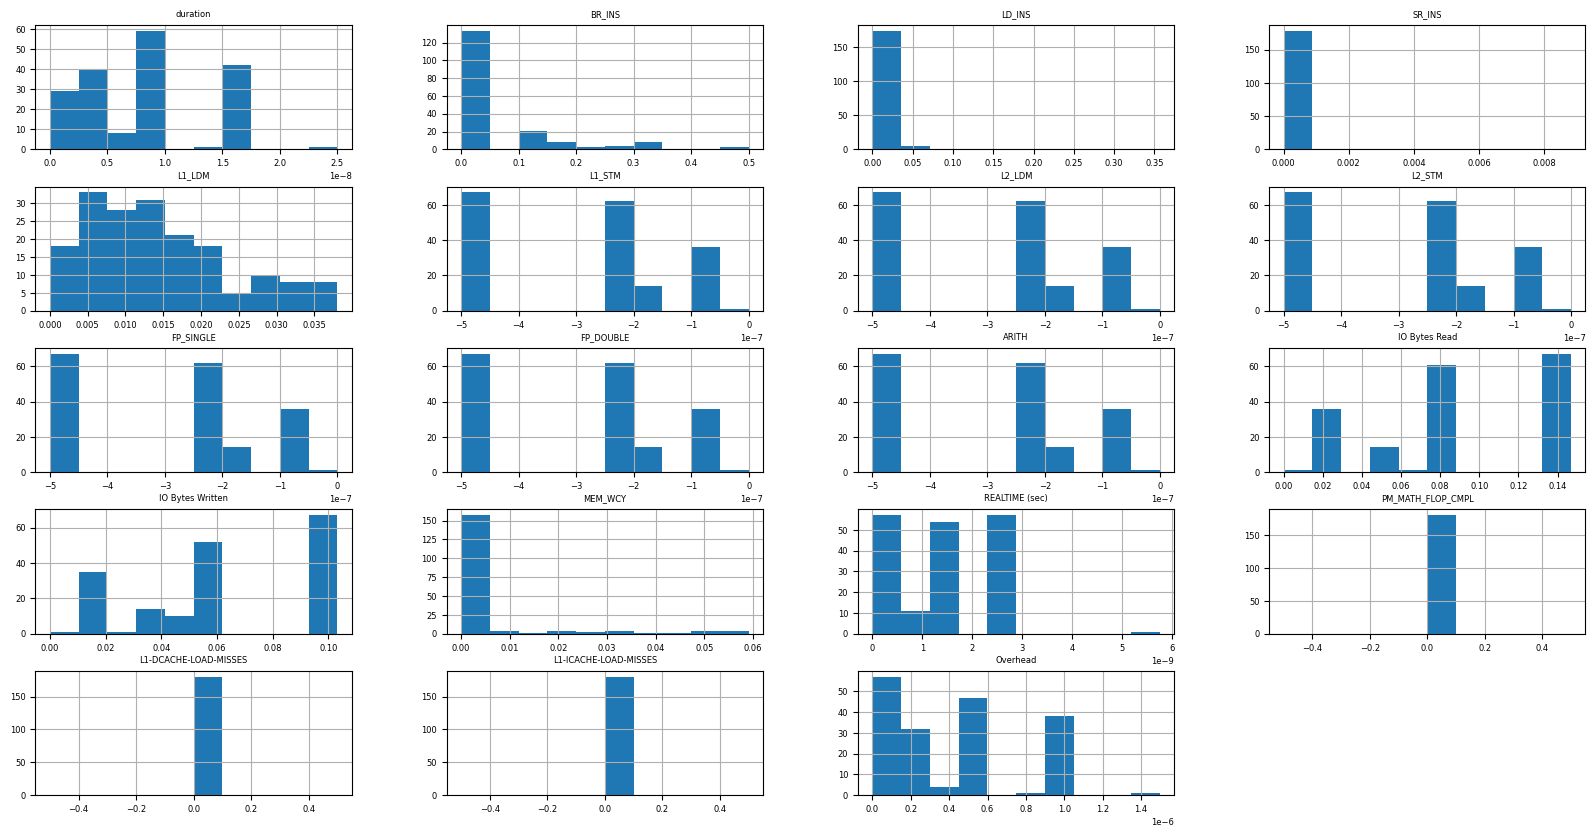

TestDfft on corona ----------------------------------------------------------------------------------



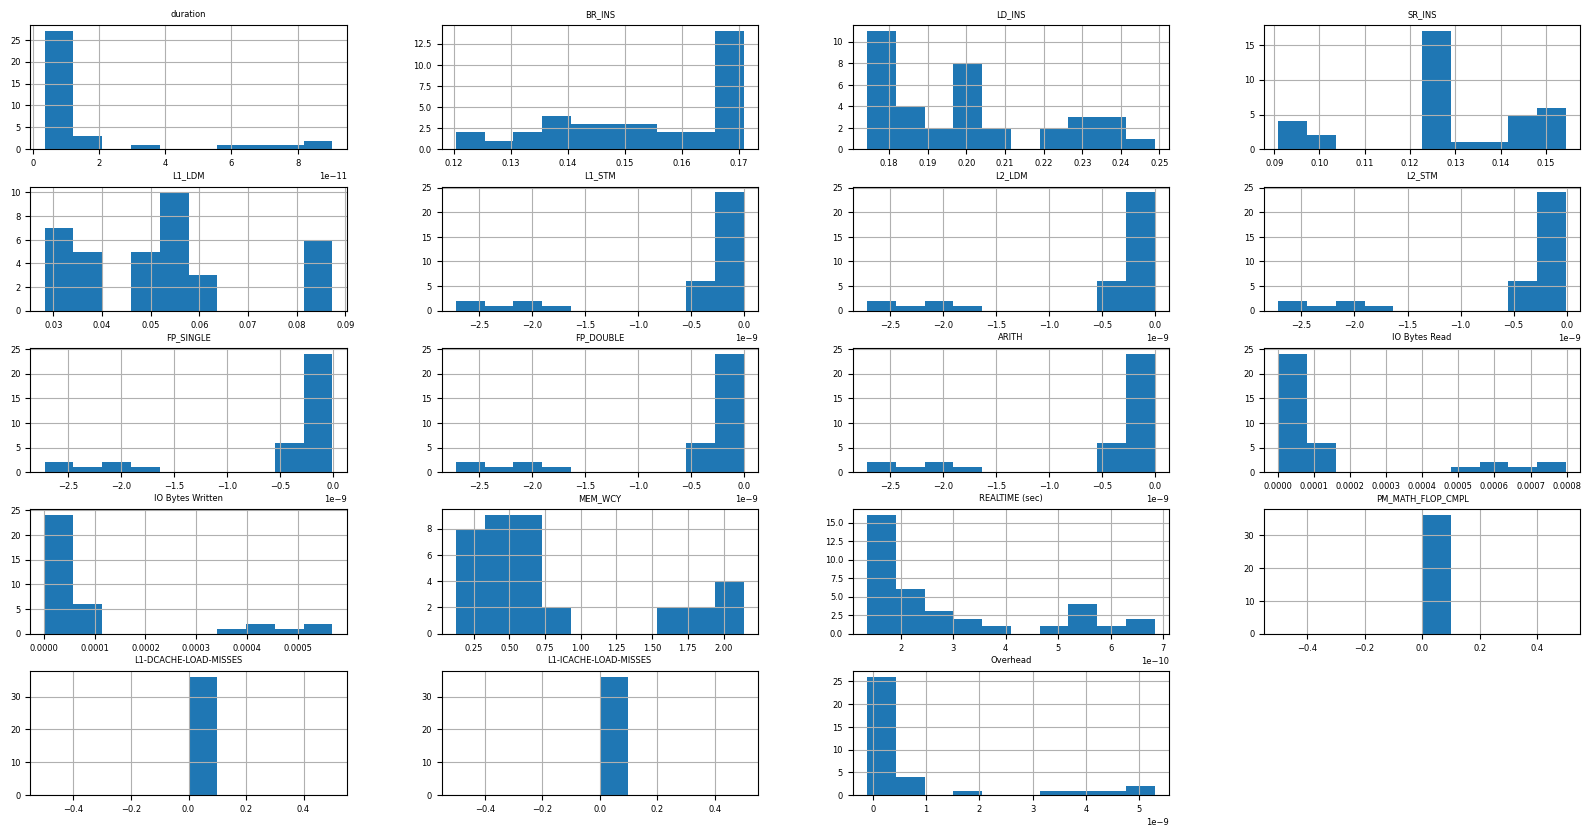

amg on corona ----------------------------------------------------------------------------------



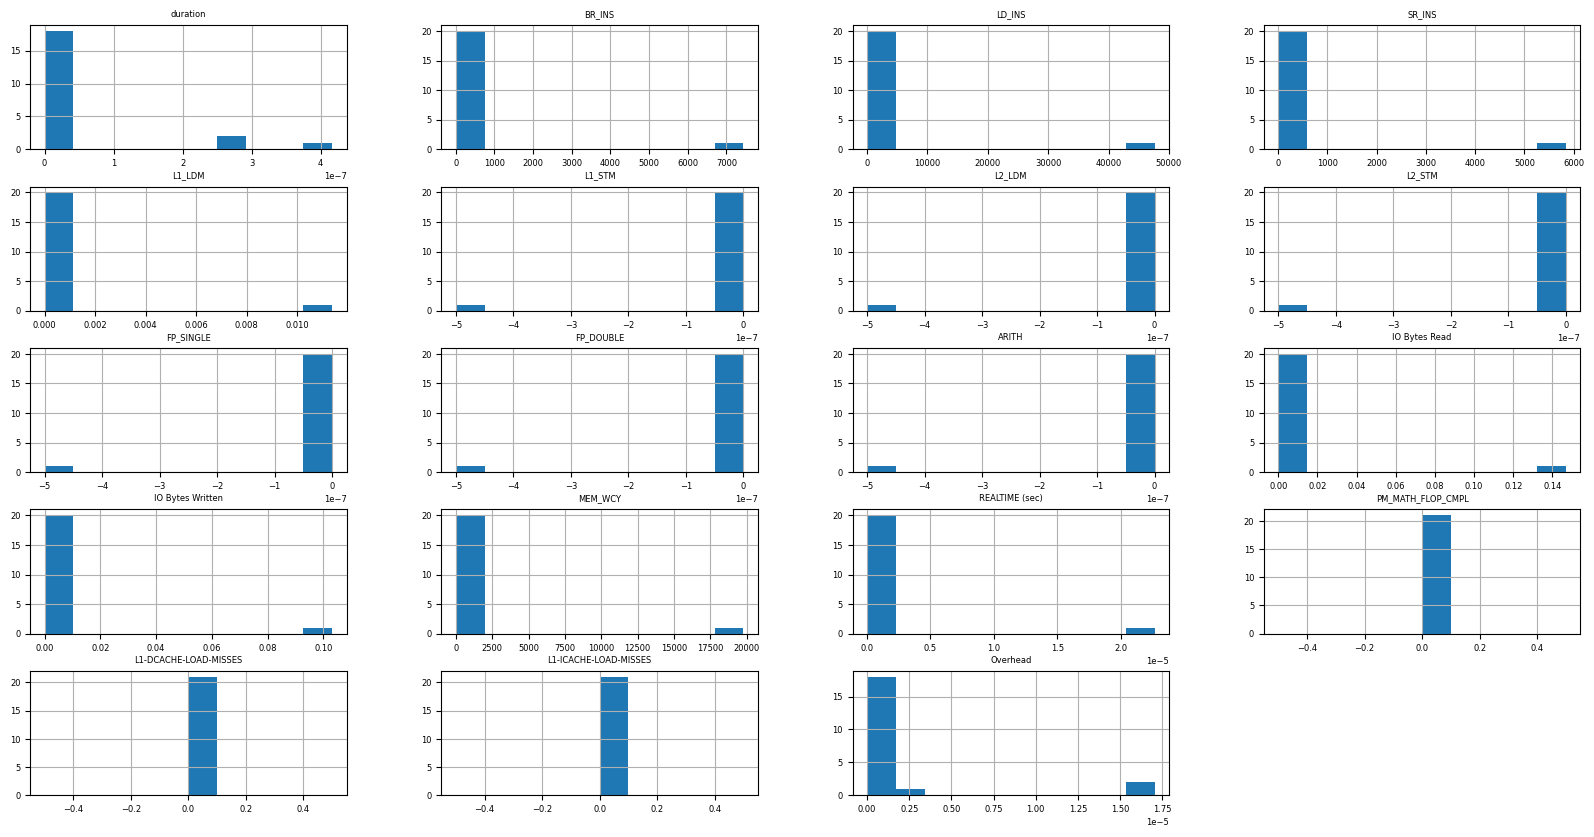

XSBench on corona ----------------------------------------------------------------------------------

miniFE.x on corona ----------------------------------------------------------------------------------



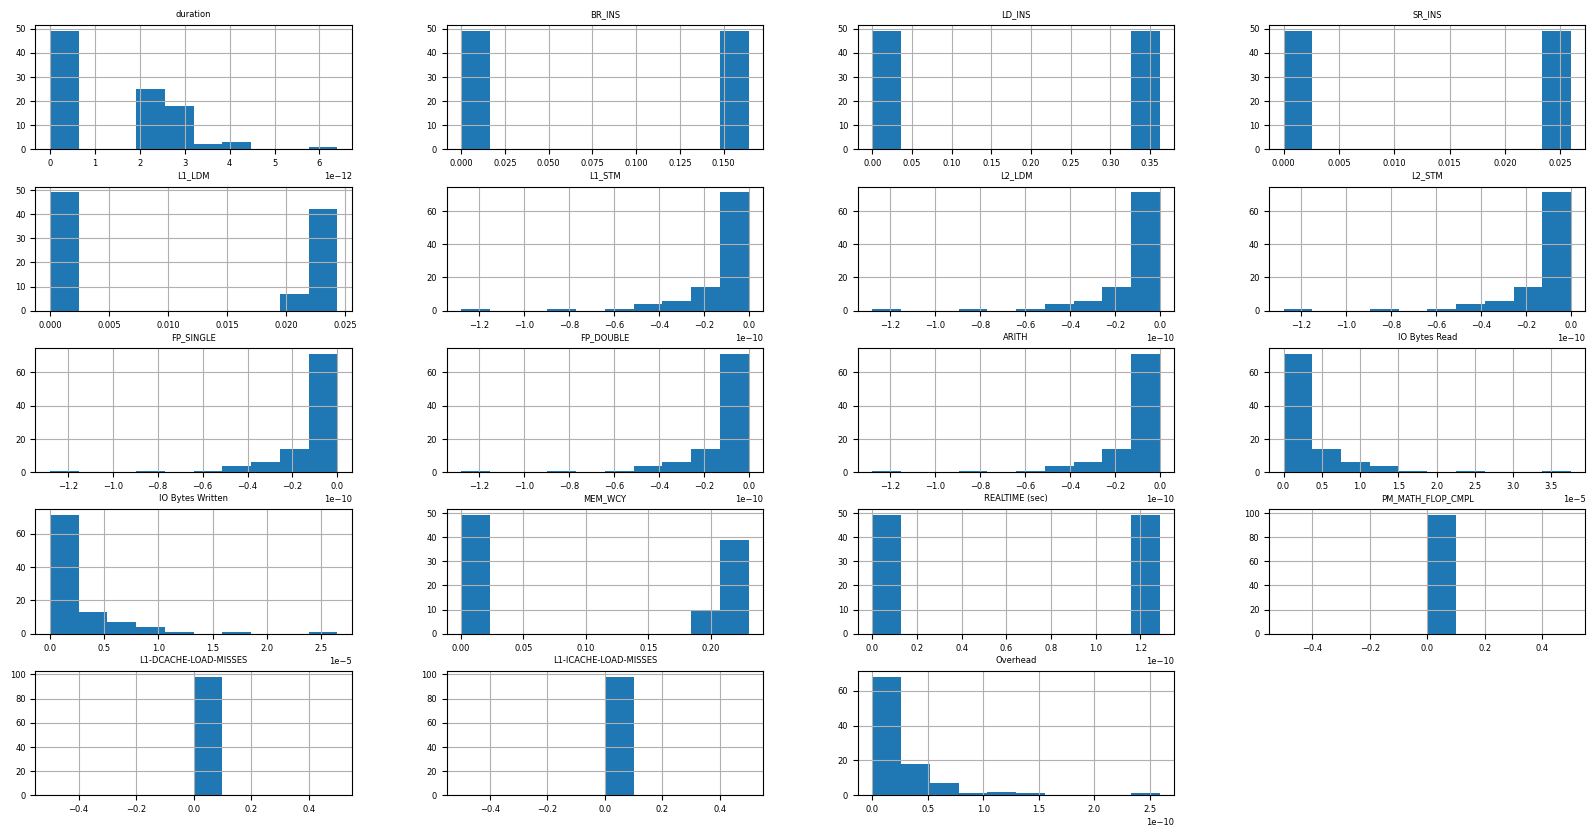

In [8]:
all_apps = refined_df['app'].unique()

for machine in all_machines:
    data_machine = refined_df.loc[refined_df['machine'] == machine]

    for app in all_apps:
        print("%s on %s ----------------------------------------------------------------------------------\n" % (app, machine))
        data_app = data_machine.loc[data_machine['app'] == app, ~refined_df.columns.isin(cols_to_exclude)]
        if data_app.empty:
            continue
        data_app.hist()
        plt.savefig('hist.' + app + '.' + machine + '.png')
        plt.show()